## 학습목표

1. **결측치**(Missing Values)를 탐지하고 적절히 처리한다
2. **이상치**(Outliers)를 탐지하는 다양한 방법을 적용한다
3. 상황에 맞는 **전처리 전략**을 선택한다
4. 전처리 전후의 데이터 품질을 **검증**한다

# 데이터 유형별 전처리 개요

본 강의를 시작하기 전에, **데이터 유형에 따른 전처리 방식의 차이** 를 이해하는 것이 중요함.

데이터는 크게 **숫자형 데이터**와 **텍스트(범주형) 데이터**로 구분되며, 각각 전처리 방식이 다르게 적용될 수 있음

## 0.1 숫자형 데이터 전처리

숫자형 데이터(Numerical Data)는 연속적인 수치 값을 가지며, **통계적 방법**을 활용한 전처리가 핵심

### 숫자형 데이터의 특징

| 특성 | 설명 | 예시 |
|------|------|------|
| **연속형** | 무한한 값을 가질 수 있음 | 온도(85.3°C), 전력(1234.5 kWh) |
| **이산형** | 정수 값만 가짐 | 불량수(15개), 생산량(100대) |
| **측정 가능** | 수학적 연산이 의미 있음 | 평균, 합계, 분산 계산 가능 |

### 숫자형 데이터 전처리 체크리스트

```
결측치 처리 → 평균, 중앙값, 보간법 대체
이상치 처리 → IQR, Z-score 기반 탐지
스케일링   → 표준화(Z), 정규화(0~1)
변환      → 로그 변환, Box-Cox 변환
파생변수  → 비율, 차이, 이동평균 등
```

## 0.2 텍스트(범주형) 데이터 전처리

텍스트 데이터는 문자열 또는 범주를 나타내며, **인코딩과 정제**가 핵심

### 텍스트 데이터의 유형

| 유형 | 설명 | 예시 |
|------|------|------|
| **명목형** | 순서 없는 범주 | 제품코드(A, B, C), 라인명 |
| **순서형** | 순서 있는 범주 | 품질등급(상, 중, 하), 우선순위 |
| **자유 텍스트** | 비정형 문자열 | 불량 원인 설명, 작업 메모 |

### 텍스트 데이터 전처리 체크리스트

```
결측치 처리 → 최빈값 대체, 'Unknown' 레이블 생성
대소문자 통일 → 'HIGH' vs 'High' vs 'high'
공백/특수문자 제거 → 정규화
인코딩 → Label Encoding, One-Hot Encoding
오탈자 수정 → 유사 문자열 매칭
```

## 0.3 숫자형 vs 텍스트 데이터 전처리 비교

| 항목 | 숫자형 데이터 | 텍스트 데이터 |
|------|-------------|--------------|
| **결측치 대체** | 평균, 중앙값, 보간 | 최빈값, 별도 범주('Unknown') |
| **이상치 처리** | IQR, Z-score | 빈도 기반, 희귀 범주 통합 |
| **변환 방법** | 스케일링, 로그 변환 | 인코딩(Label, One-Hot) |
| **주요 이슈** | 분포 왜곡, 극단값 | 고차원화, 순서 정보 손실 |
| **시각화** | 히스토그램, 상자그림 | 막대그래프, 파이차트 |

## 0.4 본 강의의 초점

> 본 강의는 숫자형 데이터 전처리에 초점을 맞추고 진행함

제조 데이터의 핵심 변수들(온도, 압력, 생산량, 에너지 소비량 등)은 대부분 숫자형 데이터이며, 이러한 연속형 변수들에서 결측치와 이상치를 어떻게 처리하느냐가 AI 모델의 성능을 좌우할 수 있음(LLMㅇ의 경우, 문자열 전처리 방식이 핵심)

텍스트/범주형 데이터의 인코딩과 처리는 **9차시(데이터 정규화와 인코딩)** 에서 다뤄볼 것임

# 1. 결측치 탐지 및 처리

## 1.1 왜 전처리가 중요한가?

### 데이터 분석의 현실

실제 데이터 분석 프로젝트에서 시간 배분을 살펴보면, **전처리가 전체 작업의 60~80%를 차지함**

```
전체 프로젝트 시간 배분:
┌──────────────────────────────────────────────────┐
│ 데이터 수집·전처리    ████████████████████  60~80% │
│ 모델링·학습          ████████  10~20%            │
│ 평가·배포·운영       ████████  10~20%            │
└──────────────────────────────────────────────────┘
```

> **"Garbage In, Garbage Out (GIGO)"**
> 
> 아무리 뛰어난 알고리즘도 나쁜 데이터로는 좋은 결과를 만들 수 없음

---

## 1.2 전처리의 목표

데이터 전처리의 핵심 목표는 **분석과 모델링에 적합한 형태로 데이터를 변환**하는 것임

| 문제 | 설명 | 해결 방법 |
|------|------|----------|
| **결측치** | 비어있는 값 | 삭제, 대체, 보간 |
| **이상치** | 극단적인 값 | 탐지, 클리핑, 대체 |
| **불균형** | 클래스 비율 불균형 | 오버/언더 샘플링 |
| **스케일** | 변수 간 단위 차이 | 표준화, 정규화 |
| **형식** | 자료형 불일치 | 인코딩, 형변환 |

---

## 1.3 결측치(Missing Values)란?

### 정의

결측치는 데이터셋에서 **기록되지 않거나 수집되지 않은 값**을 의미함(0과는 다르다)

### 제조 현장에서의 결측치 발생 원인

| 원인 | 설명 | 예시 |
|------|------|------|
| **센서 오류** | 통신 두절, 배터리 방전, 하드웨어 고장 | 온도 센서 일시적 끊김 |
| **입력 누락** | 수기 입력 시 실수, 필수 항목 미입력 | 불량수 미기록 |
| **시스템 장애** | PLC, MES, SCADA 연결 문제 | 로그 데이터 누락 |
| **정상 결측** | 특정 조건에서만 측정되는 값 | 비가동 시간의 생산량 |
| **데이터 통합** | 서로 다른 시스템 간 키 불일치 | 조인 실패로 인한 NULL |

---

## 1.4 결측치의 유형 (수학적 분류)

결측치는 발생 메커니즘에 따라 세 가지로 분류됩니다. 이 분류는 **어떤 처리 전략을 선택할지** 결정하는 데 중요하게 작용함

### MCAR (Missing Completely At Random)

**완전 무작위 결측**: 결측 발생이 어떤 변수와도 관련이 없음

$$P(\text{결측} | X_{obs}, X_{mis}) = P(\text{결측})$$

- 예: 센서의 무작위 통신 오류
- 처리: 삭제해도 편향 없음

### MAR (Missing At Random)

**무작위 결측**: 결측 발생이 관측된 다른 변수와 관련 있음

$$P(\text{결측} | X_{obs}, X_{mis}) = P(\text{결측} | X_{obs})$$

- 예: 특정 생산라인에서만 결측 많음
- 처리: 그룹별 대체 권장

### MNAR (Missing Not At Random)

**비무작위 결측**: 결측 발생이 결측값 자체와 관련 있음

$$P(\text{결측} | X_{obs}, X_{mis}) \neq P(\text{결측} | X_{obs})$$

- 예: 측정 범위를 초과하면 기록 안 됨
- 처리: 도메인 전문가 상의 필요

---

## 1.5 pandas에서 결측치 표현

Python의 pandas 라이브러리에서 결측치는 여러 방식으로 표현됨

| 표현 | 타입 | 설명 |
|------|------|------|
| `np.nan` | float | 수치형에서 주로 사용, IEEE 754 표준 |
| `None` | NoneType | Python 내장, 객체형 열에서 사용 |
| `pd.NA` | pandas.NA | pandas 1.0+ 권장, 모든 타입에서 일관됨 |

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# 결측치 표현 방식
print("=== 결측치 표현 방식 ===")
print(f"np.nan: {np.nan}")
print(f"None: {None}")
print(f"pd.NA: {pd.NA}")
print()

# DataFrame에서의 결측치 표현
df_example = pd.DataFrame({
    'NumPy_nan': [1, 2, np.nan, 4],
    'Python_None': [None, 2, 3, 4],
    'Pandas_NA': [1, pd.NA, 3, 4]
})

print("=== DataFrame에서 결측치 ===")
print(df_example)
print()

# 모두 결측으로 인식되는지 확인
print("=== 결측치 인식 확인 ===")
print(df_example.isnull())

=== 결측치 표현 방식 ===
np.nan: nan
None: None
pd.NA: <NA>

=== DataFrame에서 결측치 ===
   NumPy_nan  Python_None Pandas_NA
0        1.0          NaN         1
1        2.0          2.0      <NA>
2        NaN          3.0         3
3        4.0          4.0         4

=== 결측치 인식 확인 ===
   NumPy_nan  Python_None  Pandas_NA
0      False         True      False
1      False        False       True
2       True        False      False
3      False        False      False


## 결측치 탐지 메서드

In [3]:
# 실습용 데이터 생성
np.random.seed(42)

df = pd.DataFrame({
    '온도': [85, np.nan, 87, 86, np.nan, 88, 85.5, np.nan, 89, 87],
    '생산량': [1200, 1150, np.nan, 1180, 1190, 1200, np.nan, 1170, 1160, 1195],
    '불량수': [30, 28, 25, np.nan, 27, 29, 31, 26, np.nan, 28],
    '라인': ['A', 'A', 'B', 'B', 'A', 'C', 'C', 'B', 'A', 'C']
})

print("=== 원본 데이터 ===")
print(df)
print()

=== 원본 데이터 ===
     온도     생산량   불량수 라인
0  85.0  1200.0  30.0  A
1   NaN  1150.0  28.0  A
2  87.0     NaN  25.0  B
3  86.0  1180.0   NaN  B
4   NaN  1190.0  27.0  A
5  88.0  1200.0  29.0  C
6  85.5     NaN  31.0  C
7   NaN  1170.0  26.0  B
8  89.0  1160.0   NaN  A
9  87.0  1195.0  28.0  C



In [4]:
# 1. 전체 정보 확인
print("=== df.info() ===")
df.info()
print()

=== df.info() ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   온도      7 non-null      float64
 1   생산량     8 non-null      float64
 2   불량수     8 non-null      float64
 3   라인      10 non-null     object 
dtypes: float64(3), object(1)
memory usage: 452.0+ bytes



In [5]:
# 2. 열별 결측치 수
print("=== 열별 결측치 수 ===")
print(df.isnull().sum())
print()

=== 열별 결측치 수 ===
온도     3
생산량    2
불량수    2
라인     0
dtype: int64



In [6]:

# 3. 결측치 비율 (%)
print("=== 결측 비율 (%) ===")
missing_ratio = (df.isnull().sum() / len(df) * 100).round(2)
print(missing_ratio)
print()

=== 결측 비율 (%) ===
온도     30.0
생산량    20.0
불량수    20.0
라인      0.0
dtype: float64



In [7]:
# 4. 행별 결측치 수
print("=== 행별 결측치 수 ===")
print(df.isnull().sum(axis=1))
print()

=== 행별 결측치 수 ===
0    0
1    1
2    1
3    1
4    1
5    0
6    1
7    1
8    1
9    0
dtype: int64



In [8]:
# 5. 결측치가 있는 행만 출력
print("=== 결측치가 있는 행 ===")
print(df[df.isnull().any(axis=1)])

=== 결측치가 있는 행 ===
     온도     생산량   불량수 라인
1   NaN  1150.0  28.0  A
2  87.0     NaN  25.0  B
3  86.0  1180.0   NaN  B
4   NaN  1190.0  27.0  A
6  85.5     NaN  31.0  C
7   NaN  1170.0  26.0  B
8  89.0  1160.0   NaN  A


## 1.7 결측치 시각화

결측치의 패턴을 시각적으로 파악하면 적절한 처리 전략을 선택하는 데 도움이 될 수 있음

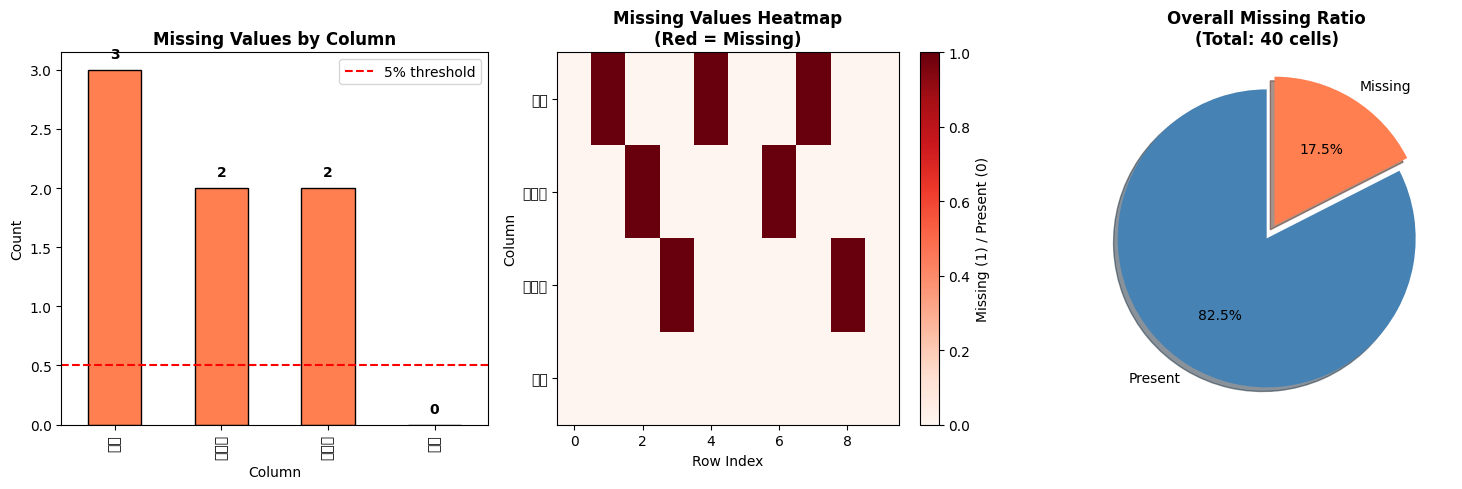

In [9]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'DejaVu Sans'  # 또는 'Malgun Gothic' (Windows)
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. 열별 결측치 수 막대그래프
ax1 = axes[0]
colors = ['coral' if v > 0 else 'steelblue' for v in df.isnull().sum()]
df.isnull().sum().plot(kind='bar', ax=ax1, color=colors, edgecolor='black')
ax1.set_title('Missing Values by Column', fontsize=12, fontweight='bold')
ax1.set_ylabel('Count')
ax1.set_xlabel('Column')
for i, v in enumerate(df.isnull().sum()):
    ax1.text(i, v + 0.1, str(v), ha='center', fontweight='bold')
ax1.axhline(y=len(df)*0.05, color='red', linestyle='--', label='5% threshold')
ax1.legend()

# 2. 결측치 히트맵
ax2 = axes[1]
im = ax2.imshow(df.isnull().T, aspect='auto', cmap='Reds', interpolation='nearest')
ax2.set_title('Missing Values Heatmap\n(Red = Missing)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Row Index')
ax2.set_ylabel('Column')
ax2.set_yticks(range(len(df.columns)))
ax2.set_yticklabels(df.columns)
plt.colorbar(im, ax=ax2, label='Missing (1) / Present (0)')

# 3. 결측 비율 파이차트 (전체 데이터 기준)
ax3 = axes[2]
total_cells = df.size
missing_cells = df.isnull().sum().sum()
present_cells = total_cells - missing_cells

ax3.pie([present_cells, missing_cells], 
        labels=['Present', 'Missing'],
        colors=['steelblue', 'coral'],
        autopct='%1.1f%%',
        explode=(0, 0.1),
        shadow=True,
        startangle=90)
ax3.set_title(f'Overall Missing Ratio\n(Total: {total_cells} cells)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('missing_values_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

## 1.9 결측치 처리 전략

### 전략 1: 삭제 (Deletion)

가장 단순하지만, **데이터 손실**이 발생한다.(경우에 따라, 크리 치명적이지는 않을 수도 있음)

#### 삭제의 수학적 의미

행 $i$를 삭제할 때의 정보 손실:

$$\text{Information Loss}_i = \sum_{j=1}^{p} I(x_{ij} \neq \text{NA})$$

여기서 $p$는 변수의 개수, $I(\cdot)$는 지시함수

**삭제 권장 조건:**
- 결측 비율 < 5%
- MCAR (완전 무작위 결측)
- 충분한 표본 크기

In [10]:
print("=== 원본 데이터 ===")
print(f"행 수: {len(df)}")
print(df)
print()

# 1. 결측치가 있는 행 전체 삭제 (listwise deletion)
df_dropped_any = df.dropna()
print("=== dropna() - 결측치 있는 행 삭제 ===")
print(f"남은 행 수: {len(df_dropped_any)} (삭제: {len(df) - len(df_dropped_any)}행)")
print(df_dropped_any)
print()

# 2. 특정 열에 결측치가 있는 행만 삭제
df_dropped_subset = df.dropna(subset=['온도'])
print("=== dropna(subset=['온도']) ===")
print(f"남은 행 수: {len(df_dropped_subset)}")
print()

# 3. 모든 값이 결측인 행만 삭제
df_dropped_all = df.dropna(how='all')
print("=== dropna(how='all') - 모든 열이 결측인 행만 삭제 ===")
print(f"남은 행 수: {len(df_dropped_all)}")
print()

# 4. 특정 개수 이상의 유효값이 있는 행만 유지
df_dropped_thresh = df.dropna(thresh=3)  # 유효값이 3개 이상인 행만 유지
print("=== dropna(thresh=3) - 유효값 3개 이상인 행만 유지 ===")
print(f"남은 행 수: {len(df_dropped_thresh)}")

=== 원본 데이터 ===
행 수: 10
     온도     생산량   불량수 라인
0  85.0  1200.0  30.0  A
1   NaN  1150.0  28.0  A
2  87.0     NaN  25.0  B
3  86.0  1180.0   NaN  B
4   NaN  1190.0  27.0  A
5  88.0  1200.0  29.0  C
6  85.5     NaN  31.0  C
7   NaN  1170.0  26.0  B
8  89.0  1160.0   NaN  A
9  87.0  1195.0  28.0  C

=== dropna() - 결측치 있는 행 삭제 ===
남은 행 수: 3 (삭제: 7행)
     온도     생산량   불량수 라인
0  85.0  1200.0  30.0  A
5  88.0  1200.0  29.0  C
9  87.0  1195.0  28.0  C

=== dropna(subset=['온도']) ===
남은 행 수: 7

=== dropna(how='all') - 모든 열이 결측인 행만 삭제 ===
남은 행 수: 10

=== dropna(thresh=3) - 유효값 3개 이상인 행만 유지 ===
남은 행 수: 10


### 전략 2: 대체 (Imputation) - 기본 방법

In [11]:
# 원본 복사
df_imputed = df.copy()

print("=== 대체 전 결측 현황 ===")
print(df_imputed.isnull().sum())
print()

# 1. 상수로 대체
df_const = df.copy()
df_const['온도'] = df_const['온도'].fillna(0)
print("상수(0) 대체 - 주의: 의미 왜곡 가능!")
print(f"온도 평균 변화: {df['온도'].mean():.2f} → {df_const['온도'].mean():.2f}")
print()

# 2. 평균으로 대체
df_mean = df.copy()
temp_mean = df_mean['온도'].mean()
df_mean['온도'] = df_mean['온도'].fillna(temp_mean)
print(f"평균({temp_mean:.2f}) 대체:")
print(f"온도 표준편차 변화: {df['온도'].std():.2f} → {df_mean['온도'].std():.2f}")
print()

# 3. 중앙값으로 대체 (이상치에 강건)
df_median = df.copy()
temp_median = df_median['온도'].median()
df_median['온도'] = df_median['온도'].fillna(temp_median)
print(f"중앙값({temp_median:.2f}) 대체:")
print(f"온도 표준편차 변화: {df['온도'].std():.2f} → {df_median['온도'].std():.2f}")
print()

# 4. 최빈값으로 대체 (범주형에 적합)
# 숫자형에서는 일반적으로 권장하지 않음

=== 대체 전 결측 현황 ===
온도     3
생산량    2
불량수    2
라인     0
dtype: int64

상수(0) 대체 - 주의: 의미 왜곡 가능!
온도 평균 변화: 86.79 → 60.75

평균(86.79) 대체:
온도 표준편차 변화: 1.41 → 1.15

중앙값(87.00) 대체:
온도 표준편차 변화: 1.41 → 1.16



#### 평균 대체의 수학적 배경

원본 데이터의 평균: $\bar{x} = \frac{1}{n_{obs}} \sum_{i: x_i \neq NA} x_i$

평균 대체 후 분산:

$$\hat{\sigma}^2_{imputed} = \frac{1}{n} \sum_{i=1}^{n} (x_i - \bar{x})^2 < \sigma^2_{true}$$

**문제점**: 평균으로 대체하면 **분산이 과소추정** 될 위험이 있음

In [12]:
# 분산 과소추정 시뮬레이션
np.random.seed(42)
original = np.random.normal(100, 10, 100)
with_missing = original.copy()
missing_idx = np.random.choice(100, 20, replace=False)
with_missing[missing_idx] = np.nan

# 평균 대체
mean_imputed = np.where(np.isnan(with_missing), np.nanmean(with_missing), with_missing)

print("=== 분산 과소추정 확인 ===")
print(f"원본 데이터 분산: {np.var(original):.2f}")
print(f"평균 대체 후 분산: {np.var(mean_imputed):.2f}")
print(f"분산 감소율: {(1 - np.var(mean_imputed)/np.var(original))*100:.1f}%")

=== 분산 과소추정 확인 ===
원본 데이터 분산: 81.65
평균 대체 후 분산: 57.76
분산 감소율: 29.3%


### 전략 3: 대체 (시계열 데이터)

시계열 데이터에서는 **시간적 연속성**을 활용한 대체가 효과적일 수 있음

In [13]:
# 시계열 데이터 생성
df_ts = pd.DataFrame({
    '시간': pd.date_range('2024-01-01', periods=10, freq='h'),
    '센서값': [100, 102, np.nan, np.nan, 108, 110, np.nan, 114, 116, 118]
})
df_ts = df_ts.set_index('시간')

print("=== 원본 시계열 데이터 ===")
print(df_ts)
print()

# 1. 앞 값으로 채우기 (Forward Fill)
df_ffill = df_ts.copy()
df_ffill['센서값'] = df_ffill['센서값'].ffill()
print("=== Forward Fill (앞 값으로 채우기) ===")
print(df_ffill)
print()

# 2. 뒤 값으로 채우기 (Backward Fill)
df_bfill = df_ts.copy()
df_bfill['센서값'] = df_bfill['센서값'].bfill()
print("=== Backward Fill (뒤 값으로 채우기) ===")
print(df_bfill)
print()

# 3. 선형 보간 (Linear Interpolation)
df_linear = df_ts.copy()
df_linear['센서값'] = df_linear['센서값'].interpolate(method='linear')
print("=== Linear Interpolation (선형 보간) ===")
print(df_linear)

=== 원본 시계열 데이터 ===
                       센서값
시간                        
2024-01-01 00:00:00  100.0
2024-01-01 01:00:00  102.0
2024-01-01 02:00:00    NaN
2024-01-01 03:00:00    NaN
2024-01-01 04:00:00  108.0
2024-01-01 05:00:00  110.0
2024-01-01 06:00:00    NaN
2024-01-01 07:00:00  114.0
2024-01-01 08:00:00  116.0
2024-01-01 09:00:00  118.0

=== Forward Fill (앞 값으로 채우기) ===
                       센서값
시간                        
2024-01-01 00:00:00  100.0
2024-01-01 01:00:00  102.0
2024-01-01 02:00:00  102.0
2024-01-01 03:00:00  102.0
2024-01-01 04:00:00  108.0
2024-01-01 05:00:00  110.0
2024-01-01 06:00:00  110.0
2024-01-01 07:00:00  114.0
2024-01-01 08:00:00  116.0
2024-01-01 09:00:00  118.0

=== Backward Fill (뒤 값으로 채우기) ===
                       센서값
시간                        
2024-01-01 00:00:00  100.0
2024-01-01 01:00:00  102.0
2024-01-01 02:00:00  108.0
2024-01-01 03:00:00  108.0
2024-01-01 04:00:00  108.0
2024-01-01 05:00:00  110.0
2024-01-01 06:00:00  114.0
2024-01-01 07:00:00  

#### 선형 보간의 수학적 원리

두 점 $(t_1, y_1)$과 $(t_2, y_2)$ 사이의 시점 $t$에서의 보간값:

$$\hat{y}(t) = y_1 + \frac{(y_2 - y_1)}{(t_2 - t_1)} \times (t - t_1)$$

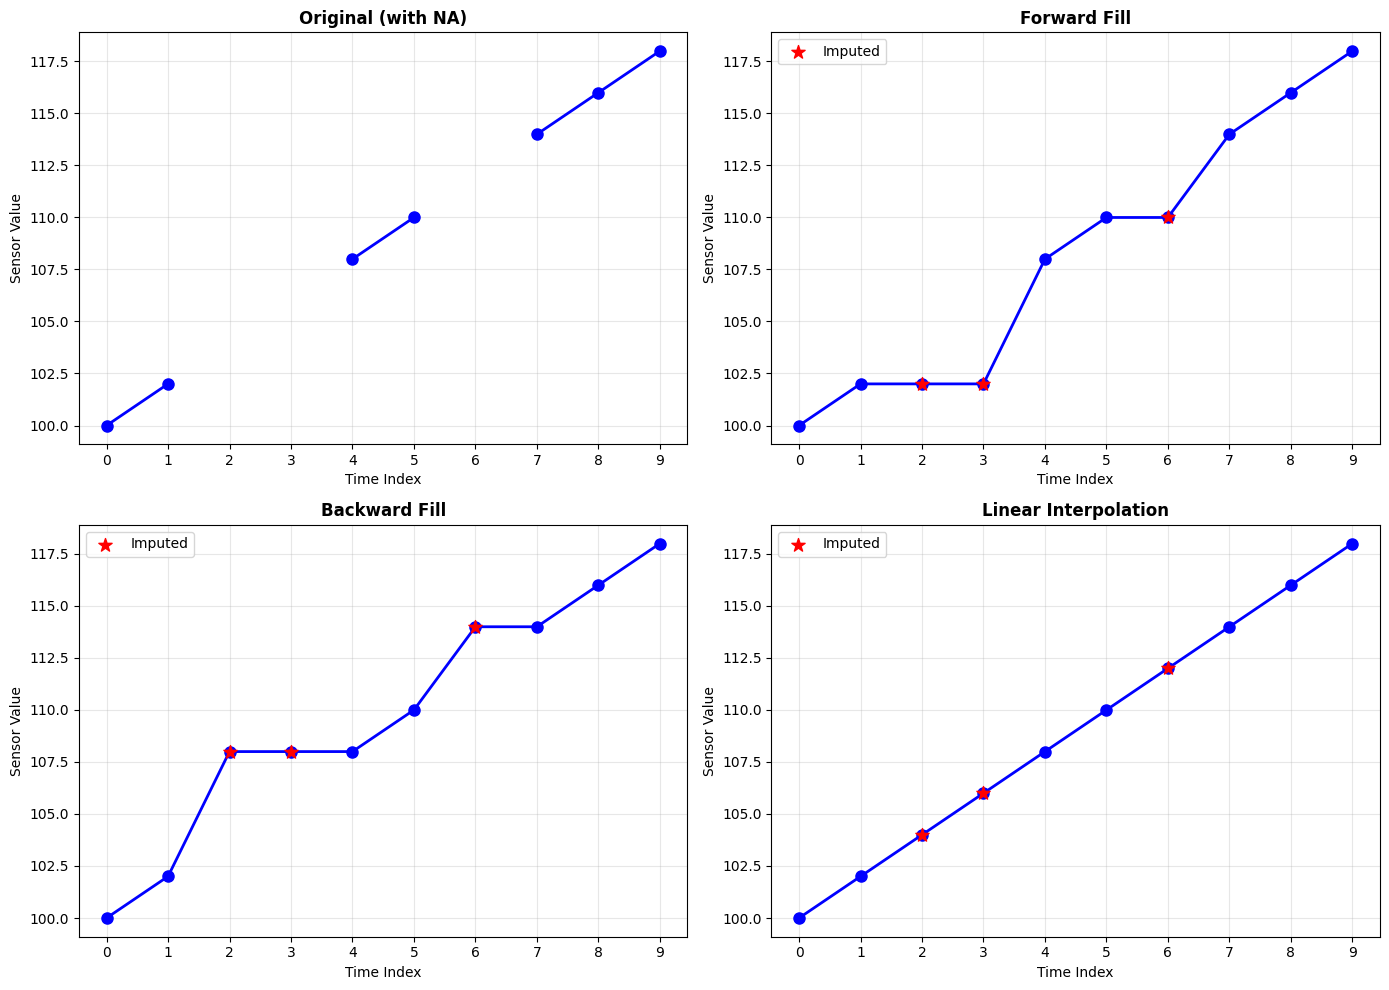

In [15]:
# 보간 방법 시각화 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

methods = [
    ('Original (with NA)', df_ts['센서값'].values),
    ('Forward Fill', df_ffill['센서값'].values),
    ('Backward Fill', df_bfill['센서값'].values),
    ('Linear Interpolation', df_linear['센서값'].values)
]

for ax, (title, values) in zip(axes.flatten(), methods):
    x = range(len(values))
    ax.plot(x, values, 'bo-', markersize=8, linewidth=2)
    
    # 원본 결측 위치 표시
    original_na_idx = np.where(pd.isna(df_ts['센서값'].values))[0]
    if title != 'Original (with NA)':
        ax.scatter(original_na_idx, values[original_na_idx], 
                   color='red', s=100, zorder=5, label='Imputed', marker='*')
        ax.legend()
    
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Time Index')
    ax.set_ylabel('Sensor Value')
    ax.grid(True, alpha=0.3)
    ax.set_xticks(x)

plt.tight_layout()
plt.show()

### 전략 4: 그룹별 대체

그룹(범주) 간 차이가 클 때는 정교하게 그룹별로 변경 조건을 따로 지정할 수 있음

In [16]:
# 그룹별 통계 확인
print("=== 라인별 온도 통계 ===")
print(df.groupby('라인')['온도'].agg(['count', 'mean', 'median', 'std']))
print()

# 그룹별 평균으로 대체
df_group = df.copy()
df_group['온도'] = df_group.groupby('라인')['온도'].transform(
    lambda x: x.fillna(x.mean())
)

print("=== 그룹별 평균 대체 결과 ===")
print(df_group[['라인', '온도']])
print()

# 전체 평균 대체 vs 그룹별 평균 대체 비교
df_global = df.copy()
df_global['온도'] = df_global['온도'].fillna(df['온도'].mean())

print("=== 대체 방법 비교 ===")
comparison = pd.DataFrame({
    '원본': df['온도'],
    '전체평균대체': df_global['온도'],
    '그룹별평균대체': df_group['온도']
})
print(comparison)

=== 라인별 온도 통계 ===
    count       mean  median       std
라인                                    
A       2  87.000000    87.0  2.828427
B       2  86.500000    86.5  0.707107
C       3  86.833333    87.0  1.258306

=== 그룹별 평균 대체 결과 ===
  라인    온도
0  A  85.0
1  A  87.0
2  B  87.0
3  B  86.0
4  A  87.0
5  C  88.0
6  C  85.5
7  B  86.5
8  A  89.0
9  C  87.0

=== 대체 방법 비교 ===
     원본     전체평균대체  그룹별평균대체
0  85.0  85.000000     85.0
1   NaN  86.785714     87.0
2  87.0  87.000000     87.0
3  86.0  86.000000     86.0
4   NaN  86.785714     87.0
5  88.0  88.000000     88.0
6  85.5  85.500000     85.5
7   NaN  86.785714     86.5
8  89.0  89.000000     89.0
9  87.0  87.000000     87.0


## 1.9 결측치 처리 가이드

### 비율별 권장 전략

| 결측 비율 | 권장 방법 | 비고 |
|----------|----------|------|
| < 5% | 삭제 또는 평균/중앙값 대체 | 영향 미미 |
| 5~15% | 중앙값, 그룹별 평균 대체 | 대체 방법 비교 필수 |
| 15~30% | 보간법, 예측 모델 대체 | 신중한 검토 필요 |
| > 30% | 열 삭제 고려 또는 전문가 상의 | 정보 손실 감수 |

### 핵심 원칙

1. **결측 패턴 먼저 파악**: MCAR, MAR, MNAR 구분
2. **도메인 지식 활용**: 왜 결측이 발생했는지 이해
3. **대체 전후 분포 비교**: 왜곡 여부 확인
4. **다중 대체 고려**: 단일 대체의 불확실성 반영

# 2. 이상치 탐지 방법 적용

---

## 2.1 이상치(Outliers)란?

### 정의

이상치는 데이터의 일반적인 패턴에서 **현저히 벗어난 관측값**

### 제조 현장에서의 이상치 발생 원인

| 원인 | 설명 | 예시 |
|------|------|------|
| **측정 오류** | 센서 고장, 캘리브레이션 문제 | 온도 -999°C |
| **입력 실수** | 단위 오류, 오타 | 생산량 12000 (실제 1200) |
| **실제 극단값** | 공정 이탈, 설비 고장 | 불량률 급등 |
| **시스템 이상** | 리셋 값, 오버플로우 | 0 또는 999999 |

---

## 2.2 이상치의 두 얼굴

> **핵심 질문: 이상치가 '오류'인가, '중요한 신호'인가?**

```
분석 목적에 따라 다름:

불량품 예측 모델:
  → 이상치가 핵심 정보! (제거하면 안 됨)

평균 생산량 추정:
  → 이상치 제거 고려 (왜곡 방지)

이상 탐지 시스템:
  → 이상치를 찾는 게 목적
```

---

## 2.3 이상치 탐지 방법 1: IQR (사분위수 범위)

### 수학적 정의

**사분위수(Quartile)**: 데이터를 크기순으로 정렬했을 때 4등분하는 값

- $Q_1$ (제1사분위수): 하위 25% 위치의 값
- $Q_2$ (제2사분위수): 중앙값 (50%)
- $Q_3$ (제3사분위수): 상위 25% 위치의 값

**사분위수 범위(IQR)**:

$$IQR = Q_3 - Q_1$$

**이상치 판정 기준**:

$$\text{Lower Bound} = Q_1 - k \times IQR$$

$$\text{Upper Bound} = Q_3 + k \times IQR$$

여기서 $k$는 보통 1.5를 사용. ($k=3$일 경우 극단적 이상치)

In [25]:
# 이상치가 포함된 데이터 생성
np.random.seed(42)
n = 100

# 정상 데이터
production = np.random.normal(1200, 50, n)

# 이상치 추가
production[5] = 2000   # 상위 이상치
production[15] = 500   # 하위 이상치
production[25] = 1800  # 상위 이상치
production[35] = 600   # 하위 이상치

df_outlier = pd.DataFrame({
    '인덱스': range(n),
    '생산량': production
})

# IQR 계산
Q1 = df_outlier['생산량'].quantile(0.25)
Q3 = df_outlier['생산량'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

print("=" * 50)
print("IQR 기반 이상치 탐지")
print("=" * 50)
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q2 (중앙값): {df_outlier['생산량'].median():.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"IQR = Q3 - Q1 = {IQR:.2f}")
print(f"\n하한(Lower Bound) = Q1 - 1.5×IQR = {lower_bound:.2f}")
print(f"상한(Upper Bound) = Q3 + 1.5×IQR = {upper_bound:.2f}")

# 이상치 탐지
outliers_iqr = (df_outlier['생산량'] < lower_bound) | (df_outlier['생산량'] > upper_bound)
print(f"\n탐지된 이상치 개수: {outliers_iqr.sum()}개")
print(f"\n이상치 목록:")
print(df_outlier[outliers_iqr])

def detect_outliers_iqr(data, factor=1.5):
    """
    IQR 방법으로 이상치 탐지
    
    Parameters:
    -----------
    data : array-like
        분석할 데이터 (Series 또는 배열)
    factor : float
        IQR 배수 (기본 1.5, 극단적 이상치는 3.0 사용)
    
    Returns:
    --------
    tuple: (이상치 마스크, 하한, 상한, 통계정보)
    
    수학적 배경:
    -----------
    - 정규분포에서 1.5×IQR 기준은 약 0.7% (상위+하위)의 데이터를 이상치로 판정
    - 3×IQR 기준은 약 0.0002%의 데이터를 이상치로 판정
    """
    Q1 = np.percentile(data.dropna(), 25)
    Q3 = np.percentile(data.dropna(), 75)
    IQR = Q3 - Q1
    
    lower = Q1 - factor * IQR
    upper = Q3 + factor * IQR
    
    outliers = (data < lower) | (data > upper)
    
    stats = {
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'lower_bound': lower,
        'upper_bound': upper,
        'n_outliers': outliers.sum(),
        'outlier_ratio': outliers.sum() / len(data) * 100
    }
    
    return outliers, lower, upper, stats

# 함수 사용 예시
outliers, lower, upper, stats = detect_outliers_iqr(df_outlier['생산량'])
print("\n=== IQR 탐지 함수 결과 ===")
for key, value in stats.items():
    print(f"{key}: {value:.2f}" if isinstance(value, float) else f"{key}: {value}")

IQR 기반 이상치 탐지
Q1 (25%): 1169.37
Q2 (중앙값): 1195.31
Q3 (75%): 1226.03
IQR = Q3 - Q1 = 56.66

하한(Lower Bound) = Q1 - 1.5×IQR = 1084.39
상한(Upper Bound) = Q3 + 1.5×IQR = 1311.02

탐지된 이상치 개수: 5개

이상치 목록:
    인덱스          생산량
5     5  2000.000000
15   15   500.000000
25   25  1800.000000
35   35   600.000000
74   74  1069.012745

=== IQR 탐지 함수 결과 ===
Q1: 1169.37
Q3: 1226.03
IQR: 56.66
lower_bound: 1084.39
upper_bound: 1311.02
n_outliers: 5
outlier_ratio: 5.00


## 2.4 이상치 탐지 방법 2: Z-score (표준점수)

Z-score는 각 데이터 포인트가 평균에서 몇 표준편차 떨어져 있는지를 나타냄

$$Z_i = \frac{x_i - \mu}{\sigma}$$

여기서:
- $x_i$: 개별 관측값
- $\mu$: 모집단 평균 (표본에서는 $\bar{x}$)
- $\sigma$: 모집단 표준편차 (표본에서는 $s$)

### 정규분포에서의 Z-score 해석

정규분포를 가정할 때, Z-score와 데이터 비율의 관계:

| Z-score 범위 | 포함 비율 | 해석 |
|-------------|----------|------|
| $\|Z\| \leq 1$ | 68.27% | 1 표준편차 이내 |
| $\|Z\| \leq 2$ | 95.45% | 2 표준편차 이내 |
| $\|Z\| \leq 3$ | 99.73% | 3 표준편차 이내 |
| $\|Z\| > 2$ | 4.55% | 주의 필요 |
| $\|Z\| > 3$ | 0.27% | 이상치로 간주 |


In [26]:
# Z-score 계산
mean = df_outlier['생산량'].mean()
std = df_outlier['생산량'].std()

z_scores = (df_outlier['생산량'] - mean) / std

print("=" * 50)
print("Z-score 기반 이상치 탐지")
print("=" * 50)
print(f"평균 (μ): {mean:.2f}")
print(f"표준편차 (σ): {std:.2f}")
print()

# Z-score 분포 확인
print("=== Z-score 분포 ===")
print(f"|Z| ≤ 1: {(np.abs(z_scores) <= 1).sum()}개 ({(np.abs(z_scores) <= 1).mean()*100:.1f}%)")
print(f"|Z| ≤ 2: {(np.abs(z_scores) <= 2).sum()}개 ({(np.abs(z_scores) <= 2).mean()*100:.1f}%)")
print(f"|Z| ≤ 3: {(np.abs(z_scores) <= 3).sum()}개 ({(np.abs(z_scores) <= 3).mean()*100:.1f}%)")
print()

# 이상치 탐지 (|Z| > 3)
outliers_zscore = np.abs(z_scores) > 3
print(f"=== |Z| > 3 이상치 ===")
print(f"탐지된 이상치 개수: {outliers_zscore.sum()}개")

# |Z| > 2 이상치 (더 민감한 기준)
outliers_zscore_2 = np.abs(z_scores) > 2
print(f"\n=== |Z| > 2 이상치 (민감한 기준) ===")
print(f"탐지된 이상치 개수: {outliers_zscore_2.sum()}개")

# 이상치 상세 정보
df_outlier['z_score'] = z_scores
print("\n=== 이상치 상세 (|Z| > 2) ===")
print(df_outlier[outliers_zscore_2][['인덱스', '생산량', 'z_score']].to_string())

def detect_outliers_zscore(data, threshold=3):
    """
    Z-score 방법으로 이상치 탐지
    
    Parameters:
    -----------
    data : array-like
        분석할 데이터
    threshold : float
        Z-score 임계값 (기본 3)
    
    Returns:
    --------
    tuple: (이상치 마스크, z_scores, 통계정보)
    
    수학적 배경:
    -----------
    정규분포 가정 시:
    - threshold=2: 약 4.55%가 이상치로 판정
    - threshold=3: 약 0.27%가 이상치로 판정
    """
    clean_data = data.dropna()
    mean = clean_data.mean()
    std = clean_data.std()
    
    z_scores = (data - mean) / std
    outliers = np.abs(z_scores) > threshold
    
    stats = {
        'mean': mean,
        'std': std,
        'threshold': threshold,
        'n_outliers': outliers.sum(),
        'outlier_ratio': outliers.sum() / len(data) * 100,
        'max_z': np.abs(z_scores).max(),
        'min_z': z_scores.min()
    }
    
    return outliers, z_scores, stats

Z-score 기반 이상치 탐지
평균 (μ): 1196.76
표준편차 (σ): 143.94

=== Z-score 분포 ===
|Z| ≤ 1: 96개 (96.0%)
|Z| ≤ 2: 96개 (96.0%)
|Z| ≤ 3: 96개 (96.0%)

=== |Z| > 3 이상치 ===
탐지된 이상치 개수: 4개

=== |Z| > 2 이상치 (민감한 기준) ===
탐지된 이상치 개수: 4개

=== 이상치 상세 (|Z| > 2) ===
    인덱스     생산량   z_score
5     5  2000.0  5.580457
15   15   500.0 -4.840705
25   25  1800.0  4.190969
35   35   600.0 -4.145961


## 2.5 IQR vs Z-score 비교

### 방법별 특성 비교

| 비교 항목 | IQR | Z-score |
|----------|-----|---------|
| **분포 가정** | 없음 (비모수적) | 정규분포 가정 |
| **이상치에 대한 강건성** | 강건함 (중앙값 기반) | 취약함 (평균, 표준편차 영향) |
| **기준** | 1.5×IQR 또는 3×IQR | 보통 $\|Z\| > 2$ 또는 3 |
| **적합한 분포** | 비대칭, 꼬리가 두꺼운 분포 | 정규분포에 가까운 분포 |
| **시각화** | 상자그림 (Boxplot) | 히스토그램 + 표준편차 |
| **계산 복잡도** | 낮음 | 낮음 |

IQR vs Z-score 비교
IQR 이상치: 5개
Z-score 이상치 (|Z|>2): 4개

공통 이상치: 4개
IQR에서만 탐지: 1개
Z-score에서만 탐지: 0개

=== 세부 비교 ===
    인덱스          생산량   z_score  IQR_이상치  Z_이상치
5     5  2000.000000  5.580457     True   True
15   15   500.000000 -4.840705     True   True
25   25  1800.000000  4.190969     True   True
35   35   600.000000 -4.145961     True   True
74   74  1069.012745 -0.887523     True  False


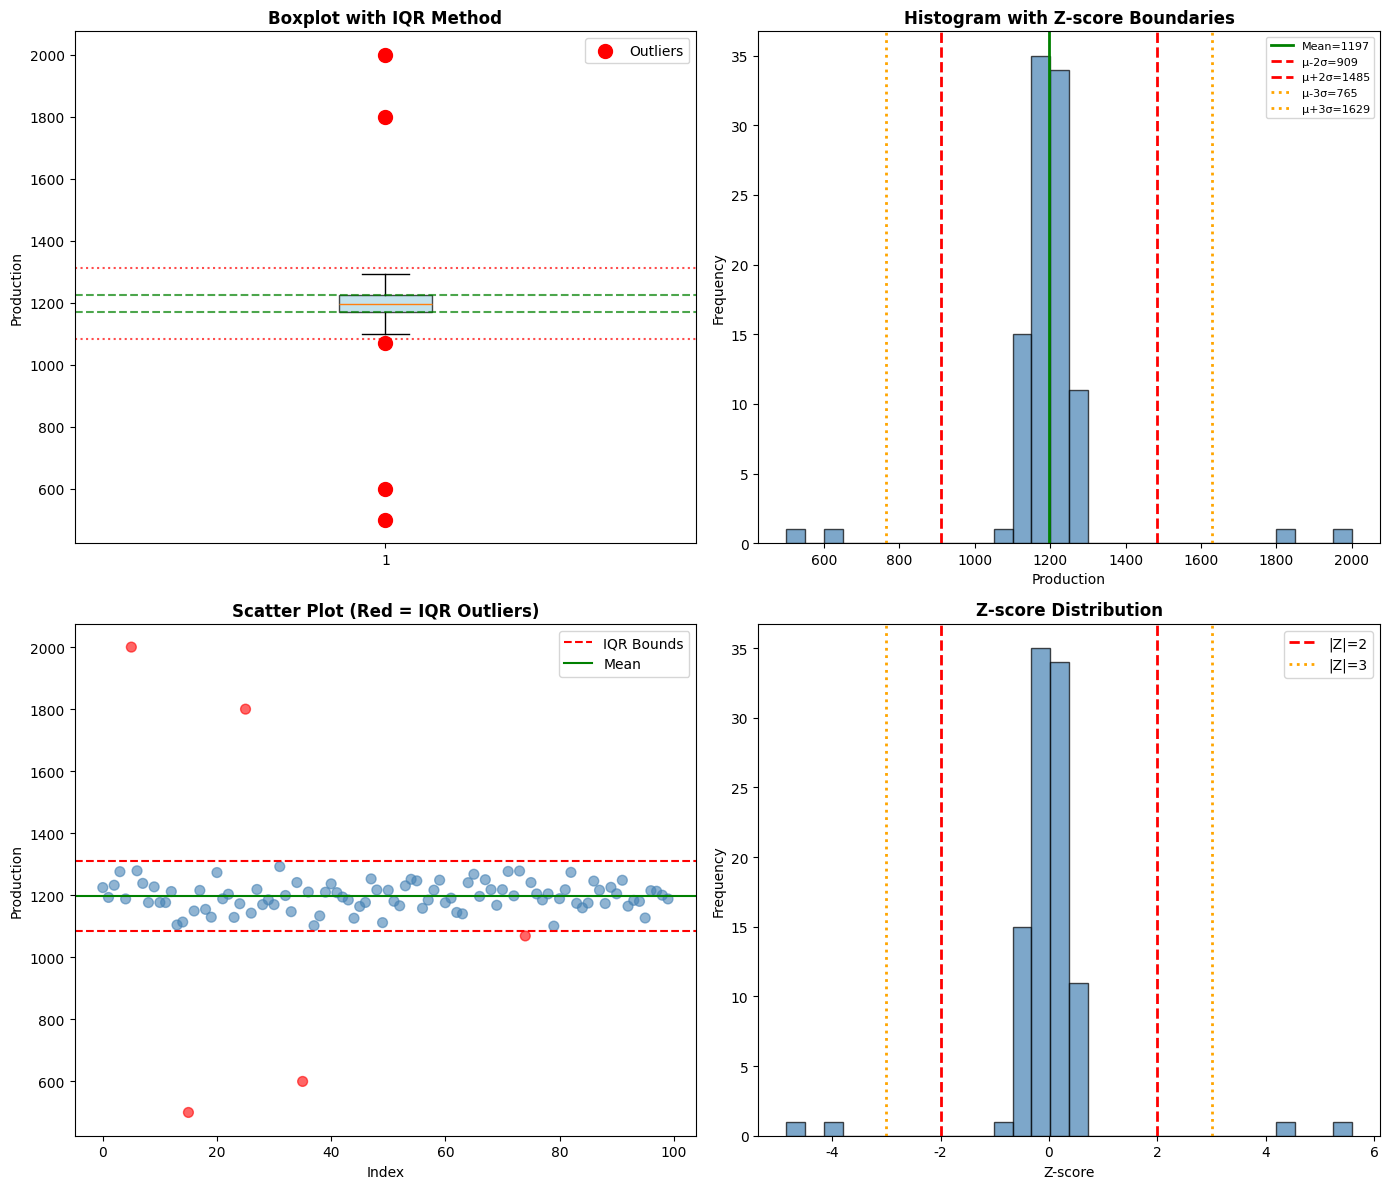

In [28]:
outliers_iqr, lower_iqr, upper_iqr, _ = detect_outliers_iqr(df_outlier['생산량'])
outliers_z, _, _ = detect_outliers_zscore(df_outlier['생산량'], threshold=2)

print("=" * 50)
print("IQR vs Z-score 비교")
print("=" * 50)
print(f"IQR 이상치: {outliers_iqr.sum()}개")
print(f"Z-score 이상치 (|Z|>2): {outliers_z.sum()}개")

# 공통 이상치
both = outliers_iqr & outliers_z
iqr_only = outliers_iqr & ~outliers_z
z_only = ~outliers_iqr & outliers_z

print(f"\n공통 이상치: {both.sum()}개")
print(f"IQR에서만 탐지: {iqr_only.sum()}개")
print(f"Z-score에서만 탐지: {z_only.sum()}개")

# 세부 비교
print("\n=== 세부 비교 ===")
df_outlier['IQR_이상치'] = outliers_iqr
df_outlier['Z_이상치'] = outliers_z
print(df_outlier[outliers_iqr | outliers_z][['인덱스', '생산량', 'z_score', 'IQR_이상치', 'Z_이상치']])

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. 상자그림
ax1 = axes[0, 0]
bp = ax1.boxplot(df_outlier['생산량'], vert=True, patch_artist=True)
bp['boxes'][0].set_facecolor('lightblue')
bp['boxes'][0].set_alpha(0.7)

# 이상치 점 강조
outlier_values = df_outlier[outliers_iqr]['생산량'].values
ax1.scatter([1]*len(outlier_values), outlier_values, color='red', s=100, zorder=5, label='Outliers')
ax1.set_title('Boxplot with IQR Method', fontsize=12, fontweight='bold')
ax1.set_ylabel('Production')
ax1.legend()

# Q1, Q3, 경계선 표시
ax1.axhline(y=Q1, color='green', linestyle='--', alpha=0.7, label=f'Q1={Q1:.0f}')
ax1.axhline(y=Q3, color='green', linestyle='--', alpha=0.7, label=f'Q3={Q3:.0f}')
ax1.axhline(y=lower_iqr, color='red', linestyle=':', alpha=0.7, label=f'Lower={lower_iqr:.0f}')
ax1.axhline(y=upper_iqr, color='red', linestyle=':', alpha=0.7, label=f'Upper={upper_iqr:.0f}')

# 2. 히스토그램 + Z-score 경계
ax2 = axes[0, 1]
n_bins = 30
ax2.hist(df_outlier['생산량'], bins=n_bins, edgecolor='black', alpha=0.7, color='steelblue')
ax2.axvline(mean, color='green', linestyle='-', linewidth=2, label=f'Mean={mean:.0f}')
ax2.axvline(mean - 2*std, color='red', linestyle='--', linewidth=2, label=f'μ-2σ={mean-2*std:.0f}')
ax2.axvline(mean + 2*std, color='red', linestyle='--', linewidth=2, label=f'μ+2σ={mean+2*std:.0f}')
ax2.axvline(mean - 3*std, color='orange', linestyle=':', linewidth=2, label=f'μ-3σ={mean-3*std:.0f}')
ax2.axvline(mean + 3*std, color='orange', linestyle=':', linewidth=2, label=f'μ+3σ={mean+3*std:.0f}')
ax2.set_title('Histogram with Z-score Boundaries', fontsize=12, fontweight='bold')
ax2.set_xlabel('Production')
ax2.set_ylabel('Frequency')
ax2.legend(fontsize=8)

# 3. 산점도 + 이상치 표시
ax3 = axes[1, 0]
colors = ['red' if o else 'steelblue' for o in outliers_iqr]
ax3.scatter(df_outlier['인덱스'], df_outlier['생산량'], c=colors, alpha=0.6, s=50)
ax3.axhline(y=lower_iqr, color='red', linestyle='--', label='IQR Bounds')
ax3.axhline(y=upper_iqr, color='red', linestyle='--')
ax3.axhline(y=mean, color='green', linestyle='-', label='Mean')
ax3.set_title('Scatter Plot (Red = IQR Outliers)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Index')
ax3.set_ylabel('Production')
ax3.legend()

# 4. Z-score 분포
ax4 = axes[1, 1]
ax4.hist(z_scores, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
ax4.axvline(2, color='red', linestyle='--', linewidth=2, label='|Z|=2')
ax4.axvline(-2, color='red', linestyle='--', linewidth=2)
ax4.axvline(3, color='orange', linestyle=':', linewidth=2, label='|Z|=3')
ax4.axvline(-3, color='orange', linestyle=':', linewidth=2)
ax4.set_title('Z-score Distribution', fontsize=12, fontweight='bold')
ax4.set_xlabel('Z-score')
ax4.set_ylabel('Frequency')
ax4.legend()

plt.tight_layout()
plt.show()

```
              데이터 분포 확인
                    │
           ┌───────┴───────┐
           │               │
    정규분포에 가까움    비대칭/꼬리 두꺼움
           │               │
           ▼               ▼
       Z-score           IQR
       (|Z|>2~3)      (1.5×IQR)
```

**권장 사항:**
- **정규분포에 가까운 경우**: Z-score 사용
- **분포 형태가 불확실한 경우**: IQR 사용 (더 강건함)
- **두 방법 모두 사용**: 교차 검증으로 신뢰성 높임

## 3.1 이상치 처리 전략

### 전략 1: 삭제

**사용 시점:**
- 이상치가 **명백한 오류**일 때
- 이상치 비율이 낮을 때 (< 5%)
- 이상치가 분석에 중요하지 않을 때


In [29]:
# 이상치 삭제
df_clean = df_outlier[~outliers_iqr].copy()

print("=== 이상치 삭제 ===")
print(f"원본 데이터: {len(df_outlier)}행")
print(f"삭제 후: {len(df_clean)}행 (삭제: {outliers_iqr.sum()}행)")
print(f"\n통계 변화:")
print(f"평균: {df_outlier['생산량'].mean():.2f} → {df_clean['생산량'].mean():.2f}")
print(f"표준편차: {df_outlier['생산량'].std():.2f} → {df_clean['생산량'].std():.2f}")

=== 이상치 삭제 ===
원본 데이터: 100행
삭제 후: 95행 (삭제: 5행)

통계 변화:
평균: 1196.76 → 1196.92
표준편차: 143.94 → 44.25


### 전략 2: 클리핑 (Winsorization)

상한/하한 값으로 제한하여 극단값의 영향을 완화

In [30]:
# 클리핑
df_clipped = df_outlier.copy()
df_clipped['생산량_clipped'] = df_clipped['생산량'].clip(lower=lower_iqr, upper=upper_iqr)

print("=== 클리핑 (Winsorization) ===")
print(f"하한: {lower_iqr:.2f}, 상한: {upper_iqr:.2f}")
print(f"\n통계 변화:")
print(f"평균: {df_outlier['생산량'].mean():.2f} → {df_clipped['생산량_clipped'].mean():.2f}")
print(f"표준편차: {df_outlier['생산량'].std():.2f} → {df_clipped['생산량_clipped'].std():.2f}")
print(f"최소: {df_outlier['생산량'].min():.2f} → {df_clipped['생산량_clipped'].min():.2f}")
print(f"최대: {df_outlier['생산량'].max():.2f} → {df_clipped['생산량_clipped'].max():.2f}")

# 클리핑된 값 확인
print("\n=== 클리핑된 데이터 포인트 ===")
clipped_mask = df_clipped['생산량'] != df_clipped['생산량_clipped']
print(df_clipped[clipped_mask][['인덱스', '생산량', '생산량_clipped']])

=== 클리핑 (Winsorization) ===
하한: 1084.39, 상한: 1311.02

통계 변화:
평균: 1196.76 → 1195.82
표준편차: 143.94 → 50.05
최소: 500.00 → 1084.39
최대: 2000.00 → 1311.02

=== 클리핑된 데이터 포인트 ===
    인덱스          생산량  생산량_clipped
5     5  2000.000000  1311.015816
15   15   500.000000  1084.385719
25   25  1800.000000  1311.015816
35   35   600.000000  1084.385719
74   74  1069.012745  1084.385719


### 전략 3: 대체

In [31]:
# 중앙값으로 대체
df_replaced = df_outlier.copy()
median_val = df_replaced['생산량'].median()
df_replaced.loc[outliers_iqr, '생산량_replaced'] = median_val
df_replaced['생산량_replaced'] = df_replaced['생산량_replaced'].fillna(df_replaced['생산량'])

print("=== 중앙값 대체 ===")
print(f"중앙값: {median_val:.2f}")
print(f"\n대체된 데이터 포인트:")
print(df_replaced[outliers_iqr][['인덱스', '생산량', '생산량_replaced']])

=== 중앙값 대체 ===
중앙값: 1195.31

대체된 데이터 포인트:
    인덱스          생산량  생산량_replaced
5     5  2000.000000    1195.30854
15   15   500.000000    1195.30854
25   25  1800.000000    1195.30854
35   35   600.000000    1195.30854
74   74  1069.012745    1195.30854


### 전략 4: 플래그 표시

In [32]:
# 이상치 플래그 열 추가
df_flagged = df_outlier.copy()
df_flagged['이상치_여부'] = outliers_iqr
df_flagged['이상치_유형'] = 'normal'
df_flagged.loc[df_flagged['생산량'] > upper_iqr, '이상치_유형'] = 'high'
df_flagged.loc[df_flagged['생산량'] < lower_iqr, '이상치_유형'] = 'low'

# 원본 보존 + 처리된 값 추가
df_flagged['생산량_원본'] = df_flagged['생산량']
df_flagged['생산량_처리'] = df_flagged['생산량'].clip(lower_iqr, upper_iqr)

print("=== 플래그 표시 + 원본 보존 ===")
print(df_flagged[outliers_iqr][['인덱스', '생산량_원본', '생산량_처리', '이상치_유형']])

=== 플래그 표시 + 원본 보존 ===
    인덱스       생산량_원본       생산량_처리 이상치_유형
5     5  2000.000000  1311.015816   high
15   15   500.000000  1084.385719    low
25   25  1800.000000  1311.015816   high
35   35   600.000000  1084.385719    low
74   74  1069.012745  1084.385719    low


## 3.2 분석 목적별 전처리 전략

| 분석 목적 | 결측치 처리 | 이상치 처리 | 비고 |
|----------|------------|------------|------|
| **평균/합계 추정** | 중앙값 대체 | 클리핑 또는 삭제 | 왜곡 방지 |
| **예측 모델 학습** | 평균/보간 대체 | 클리핑 + 플래그 | 극단값 영향 완화 |
| **불량품 예측** | 삭제 또는 대체 | 유지 (중요 신호!) | 이상치가 핵심 |
| **이상 탐지 시스템** | 플래그 표시 | 유지 (찾는 대상) | 원본 보존 |
| **탐색적 분석** | 플래그 표시 | 분리 분석 | 패턴 파악 |


## 3.3 수치형자료 전처리 파이프라인(예시)

In [33]:
def preprocess_manufacturing_data(df, numeric_cols=None, categorical_cols=None, 
                                   missing_strategy='median', outlier_strategy='clip',
                                   outlier_method='iqr', outlier_threshold=1.5):
    """
    제조 데이터 전처리 파이프라인
    
    Parameters:
    -----------
    df : pandas.DataFrame
        원본 데이터
    numeric_cols : list
        수치형 열 목록 (None이면 자동 탐지)
    categorical_cols : list
        범주형 열 목록 (None이면 자동 탐지)
    missing_strategy : str
        결측치 처리 전략 ('mean', 'median', 'drop')
    outlier_strategy : str
        이상치 처리 전략 ('clip', 'remove', 'flag')
    outlier_method : str
        이상치 탐지 방법 ('iqr', 'zscore')
    outlier_threshold : float
        이상치 탐지 임계값 (IQR: 1.5, Z-score: 3)
    
    Returns:
    --------
    tuple: (처리된 DataFrame, 처리 로그)
    """
    df_processed = df.copy()
    log = {'missing': {}, 'outliers': {}}
    
    # 열 타입 자동 탐지
    if numeric_cols is None:
        numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    if categorical_cols is None:
        categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    
    print(f"수치형 열: {numeric_cols}")
    print(f"범주형 열: {categorical_cols}")
    print()
    
    # 1. 결측치 처리
    print("Step 1: 결측치 처리")
    for col in numeric_cols:
        missing_count = df_processed[col].isnull().sum()
        if missing_count > 0:
            if missing_strategy == 'median':
                fill_value = df_processed[col].median()
                df_processed[col] = df_processed[col].fillna(fill_value)
            elif missing_strategy == 'mean':
                fill_value = df_processed[col].mean()
                df_processed[col] = df_processed[col].fillna(fill_value)
            elif missing_strategy == 'drop':
                df_processed = df_processed.dropna(subset=[col])
                fill_value = 'dropped'
            
            log['missing'][col] = {
                'count': missing_count,
                'strategy': missing_strategy,
                'fill_value': fill_value
            }
            print(f"  - {col}: {missing_count}개 결측 → {missing_strategy} ({fill_value})")
    
    print()
    
    # 2. 이상치 처리
    print("Step 2: 이상치 처리")
    for col in numeric_cols:
        if outlier_method == 'iqr':
            outliers, lower, upper, stats = detect_outliers_iqr(
                df_processed[col], factor=outlier_threshold
            )
        else:  # zscore
            outliers, _, stats = detect_outliers_zscore(
                df_processed[col], threshold=outlier_threshold
            )
            lower = stats['mean'] - outlier_threshold * stats['std']
            upper = stats['mean'] + outlier_threshold * stats['std']
        
        n_outliers = outliers.sum()
        
        if n_outliers > 0:
            if outlier_strategy == 'clip':
                df_processed[col] = df_processed[col].clip(lower, upper)
            elif outlier_strategy == 'remove':
                df_processed = df_processed[~outliers]
            elif outlier_strategy == 'flag':
                df_processed[f'{col}_이상치'] = outliers
            
            log['outliers'][col] = {
                'count': n_outliers,
                'method': outlier_method,
                'strategy': outlier_strategy,
                'lower': lower,
                'upper': upper
            }
            print(f"  - {col}: {n_outliers}개 이상치 → {outlier_strategy}")
    
    print()
    print("=" * 60)
    print("전처리 완료")
    print(f"최종 데이터 크기: {df_processed.shape}")
    print("=" * 60)
    
    return df_processed, log

# 파이프라인 테스트
df_test = df_outlier.copy()
df_test['온도'] = np.random.normal(85, 5, len(df_test))
df_test.loc[[10, 20, 30], '온도'] = np.nan  # 결측치 추가

df_processed, process_log = preprocess_manufacturing_data(
    df_test,
    numeric_cols=['생산량', '온도'],
    missing_strategy='median',
    outlier_strategy='clip',
    outlier_method='iqr'
)

수치형 열: ['생산량', '온도']
범주형 열: []

Step 1: 결측치 처리
  - 온도: 3개 결측 → median (85.4982568254382)

Step 2: 이상치 처리
  - 생산량: 5개 이상치 → clip
  - 온도: 2개 이상치 → clip

전처리 완료
최종 데이터 크기: (100, 6)


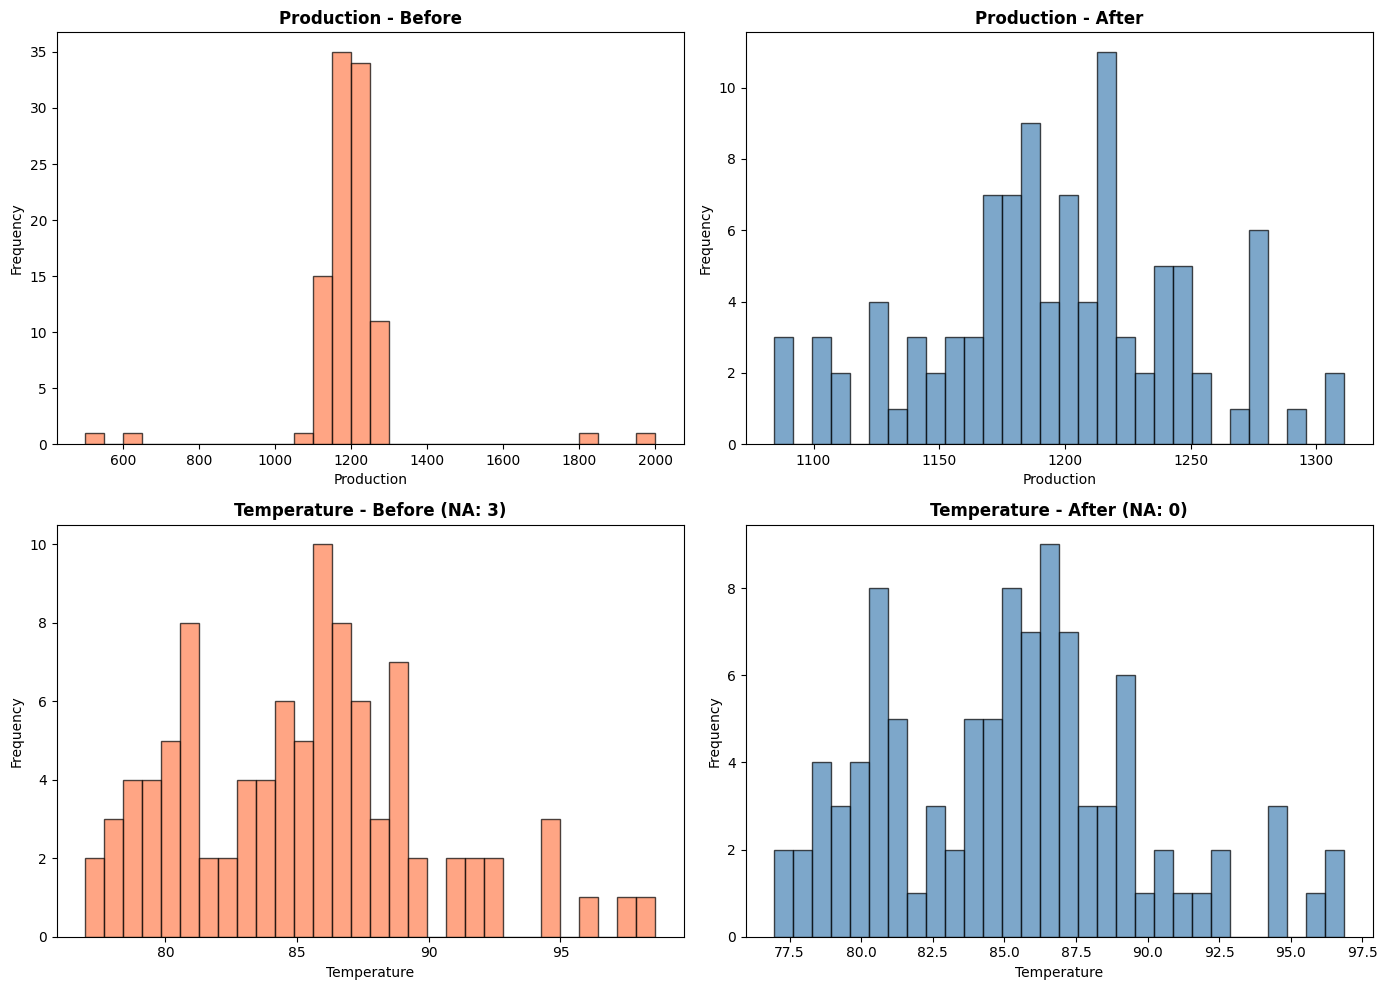

In [35]:
# 시각적 비교
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 생산량 전후 비교
axes[0, 0].hist(df_test['생산량'], bins=30, alpha=0.7, label='Before', color='coral', edgecolor='black')
axes[0, 0].set_title('Production - Before', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Production')
axes[0, 0].set_ylabel('Frequency')

axes[0, 1].hist(df_processed['생산량'], bins=30, alpha=0.7, label='After', color='steelblue', edgecolor='black')
axes[0, 1].set_title('Production - After', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Production')
axes[0, 1].set_ylabel('Frequency')

# 온도 전후 비교
axes[1, 0].hist(df_test['온도'].dropna(), bins=30, alpha=0.7, label='Before', color='coral', edgecolor='black')
axes[1, 0].set_title(f'Temperature - Before (NA: {df_test["온도"].isna().sum()})', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Temperature')
axes[1, 0].set_ylabel('Frequency')

axes[1, 1].hist(df_processed['온도'], bins=30, alpha=0.7, label='After', color='steelblue', edgecolor='black')
axes[1, 1].set_title(f'Temperature - After (NA: {df_processed["온도"].isna().sum()})', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Temperature')
axes[1, 1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## 전처리 주의사항

### 피해야 할 실수

| 실수 | 문제점 | 올바른 방법 |
|------|--------|------------|
| 결측치를 0으로 채움 | 의미 왜곡 (0이 유효한 값일 수 있음) | 평균/중앙값 대체 |
| 이상치 무조건 제거 | 정보 손실 (중요 신호일 수 있음) | 원인 파악 후 결정 |
| 전체 데이터로 대체값 계산 | 데이터 누출 | 학습 데이터만 사용 |
| 전후 비교 안 함 | 왜곡 미발견 | 분포 비교 필수 |

## 3.4 데이터 누출 (Data Leakage) 주의

In [36]:
from sklearn.model_selection import train_test_split

# 데이터 누출 예시
np.random.seed(42)
X = np.random.randn(100)
X[np.random.choice(100, 10)] = np.nan

# 잘못된 방법: 전체 데이터로 평균 계산 후 분할
X_wrong = X.copy()
X_wrong[np.isnan(X_wrong)] = np.nanmean(X_wrong)  # 전체 평균
X_train_wrong, X_test_wrong = train_test_split(X_wrong, test_size=0.2, random_state=42)

# 올바른 방법: 분할 후 학습 데이터로만 평균 계산
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
train_mean = np.nanmean(X_train)
X_train_correct = X_train.copy()
X_test_correct = X_test.copy()
X_train_correct[np.isnan(X_train_correct)] = train_mean
X_test_correct[np.isnan(X_test_correct)] = train_mean  # 학습 데이터 평균 사용!

print("=" * 60)
print("데이터 누출 예방")
print("=" * 60)
print(f"전체 데이터 평균: {np.nanmean(X):.4f}")
print(f"학습 데이터 평균: {train_mean:.4f}")
print()
print("잘못된 방법: 테스트 데이터 정보가 학습에 사용됨")
print("올바른 방법: 학습 데이터만으로 대체값 계산")

데이터 누출 예방
전체 데이터 평균: -0.1234
학습 데이터 평균: -0.1174

잘못된 방법: 테스트 데이터 정보가 학습에 사용됨
올바른 방법: 학습 데이터만으로 대체값 계산


# 4. 실제 제조 데이터를 대상으로 ㅈ거용

---

## 4.1 실습 데이터 소개: SECOM 반도체 제조 데이터

### 데이터셋 개요

본 실습에서는 **UCI Machine Learning Repository**의 **SECOM(Semiconductor Manufacturing) 데이터셋**을 사용

| 항목 | 내용 |
|------|------|
| **출처** | UCI Machine Learning Repository |
| **URL** | https://archive.ics.uci.edu/dataset/179/secom |
| **수집처** | 반도체 웨이퍼 제조 생산라인 |
| **샘플 수** | 1,567개 |
| **특성 수** | 590개 (센서 측정값) |
| **결측치** | 41,951개 (전체의 **4.52%**) |
| **클래스** | Pass(-1) / Fail(1), 불균형 비율 약 14:1 |

### 데이터의 특징

이 데이터셋은 **실제 제조 현장의 결측치 문제**를 잘 보여줍니다:
- 590개의 센서 중 **538개 열에 결측치** 존재
- 일부 센서는 **91% 이상의 결측률**
- 클래스 불균형 (양품 93.4%, 불량품 6.6%)
- 다양한 센서 데이터로 **이상치**도 존재


In [71]:
# ucimlrepo 설치: pip install ucimlrepo
from ucimlrepo import fetch_ucirepo

# SECOM 데이터셋 로드
secom = fetch_ucirepo(id=179)

# 데이터 추출
secom_df = secom.data.original.copy()
secom_df.columns = [f'sensor_{i}' for i in range(X.shape[1])]

In [72]:
X.head()

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_582,sensor_583,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,sensor_591
0,-1,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,-1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,1,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,-1,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,-1,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432


In [67]:
# 비표준 패키지이므로, 필요에 따라 설치해야할 수 있음
#!pip install ucimlrepo

In [68]:
def analyze_missing(df, show_details=True):
    """
    데이터프레임의 결측치 현황을 종합 분석하는 함수
    
    Parameters:
    -----------
    df : pandas.DataFrame
        분석할 데이터프레임
    show_details : bool
        상세 정보 출력 여부
    
    Returns:
    --------
    pandas.DataFrame
        결측치 분석 결과
    """
    # 결측 현황 계산
    missing_count = df.isnull().sum()
    missing_percent = (df.isnull().sum() / len(df) * 100).round(2)
    data_type = df.dtypes
    non_null_count = df.notnull().sum()
    
    # 결과 데이터프레임 생성
    result = pd.DataFrame({
        '결측수': missing_count,
        '결측비율(%)': missing_percent,
        '유효값수': non_null_count,
        '데이터타입': data_type
    })
    
    # 결측 비율 기준 정렬
    result = result.sort_values('결측비율(%)', ascending=False)
    
    if show_details:
        print("=" * 60)
        print("결측치 현황 분석 보고서")
        print("=" * 60)
        print(f"전체 행 수: {len(df):,}개")
        print(f"전체 열 수: {len(df.columns)}개")
        print(f"결측치가 있는 열: {(missing_count > 0).sum()}개")
        print(f"전체 결측치 수: {df.isnull().sum().sum():,}개")
        print(f"전체 셀 대비 결측 비율: {(df.isnull().sum().sum() / df.size * 100):.2f}%")
        print("=" * 60)
        print("\n열별 결측 현황:")
        print(result)
        print()
        
        # 결측 비율에 따른 권장 처리 방안
        print("권장 처리 방안:")
        for col in result.index:
            pct = result.loc[col, '결측비율(%)']
            if pct == 0:
                continue
            elif pct < 5:
                print(f"  - {col}: {pct}% → 삭제 또는 단순 대체 가능")
            elif pct < 15:
                print(f"  - {col}: {pct}% → 중앙값/그룹별 평균 대체 권장")
            elif pct < 30:
                print(f"  - {col}: {pct}% → 보간법 또는 예측 모델 대체 검토")
            else:
                print(f"  - {col}: {pct}% → 열 삭제 또는 전문가 상의 필요")
    
    return result

In [73]:
missing_report = analyze_missing(secom_df)

결측치 현황 분석 보고서
전체 행 수: 1,567개
전체 열 수: 592개
결측치가 있는 열: 538개
전체 결측치 수: 41,951개
전체 셀 대비 결측 비율: 4.52%

열별 결측 현황:
             결측수  결측비율(%)  유효값수    데이터타입
sensor_160  1429    91.19   138  float64
sensor_159  1429    91.19   138  float64
sensor_295  1429    91.19   138  float64
sensor_294  1429    91.19   138  float64
sensor_494  1341    85.58   226  float64
...          ...      ...   ...      ...
sensor_22      0     0.00  1567  float64
sensor_572     0     0.00  1567  float64
sensor_573     0     0.00  1567  float64
sensor_574     0     0.00  1567  float64
sensor_575     0     0.00  1567  float64

[592 rows x 4 columns]

권장 처리 방안:
  - sensor_160: 91.19% → 열 삭제 또는 전문가 상의 필요
  - sensor_159: 91.19% → 열 삭제 또는 전문가 상의 필요
  - sensor_295: 91.19% → 열 삭제 또는 전문가 상의 필요
  - sensor_294: 91.19% → 열 삭제 또는 전문가 상의 필요
  - sensor_494: 85.58% → 열 삭제 또는 전문가 상의 필요
  - sensor_360: 85.58% → 열 삭제 또는 전문가 상의 필요
  - sensor_87: 85.58% → 열 삭제 또는 전문가 상의 필요
  - sensor_222: 85.58% → 열 삭제 또는 전문가 상의 필요
  - sensor_113: 64.96%

In [75]:
# 센서 열만 선택
sensor_cols = [col for col in secom_df.columns if col.startswith('sensor_')]

# 전체 결측치 통계
total_missing = secom_df[sensor_cols].isnull().sum().sum()
total_cells = secom_df[sensor_cols].size

print(f"총 결측치 수: {total_missing:,}개")
print(f"전체 셀 수: {total_cells:,}개")
print(f"결측률: {(total_missing/total_cells)*100:.2f}%")

# 열별 결측치 분포
missing_by_col = secom_df[sensor_cols].isnull().sum()
cols_with_missing = missing_by_col[missing_by_col > 0]
print(f"\n결측치가 있는 센서 수: {len(cols_with_missing)} / {len(sensor_cols)}")

총 결측치 수: 41,951개
전체 셀 수: 927,664개
결측률: 4.52%

결측치가 있는 센서 수: 538 / 592


In [76]:
# 결측률 구간별 분류
missing_pct = (missing_by_col / len(secom_df) * 100)

print("\n=== 결측률 구간별 센서 수 ===")
print(f"결측률 > 50%: {(missing_pct > 50).sum()}개 센서")
print(f"결측률 20~50%: {((missing_pct > 20) & (missing_pct <= 50)).sum()}개 센서")
print(f"결측률 5~20%: {((missing_pct > 5) & (missing_pct <= 20)).sum()}개 센서")
print(f"결측률 < 5%: {(missing_pct <= 5).sum()}개 센서 (0% 포함)")
print(f"결측률 0%: {(missing_pct == 0).sum()}개 센서")

# 상위 결측 센서
print("\n=== 결측률 상위 10개 센서 ===")
top_missing = pd.DataFrame({
    '결측수': missing_by_col,
    '결측률(%)': missing_pct.round(2)
}).sort_values('결측률(%)', ascending=False).head(10)
print(top_missing)


=== 결측률 구간별 센서 수 ===
결측률 > 50%: 28개 센서
결측률 20~50%: 4개 센서
결측률 5~20%: 20개 센서
결측률 < 5%: 540개 센서 (0% 포함)
결측률 0%: 54개 센서

=== 결측률 상위 10개 센서 ===
             결측수  결측률(%)
sensor_160  1429   91.19
sensor_159  1429   91.19
sensor_295  1429   91.19
sensor_294  1429   91.19
sensor_494  1341   85.58
sensor_360  1341   85.58
sensor_87   1341   85.58
sensor_222  1341   85.58
sensor_113  1018   64.96
sensor_518  1018   64.96


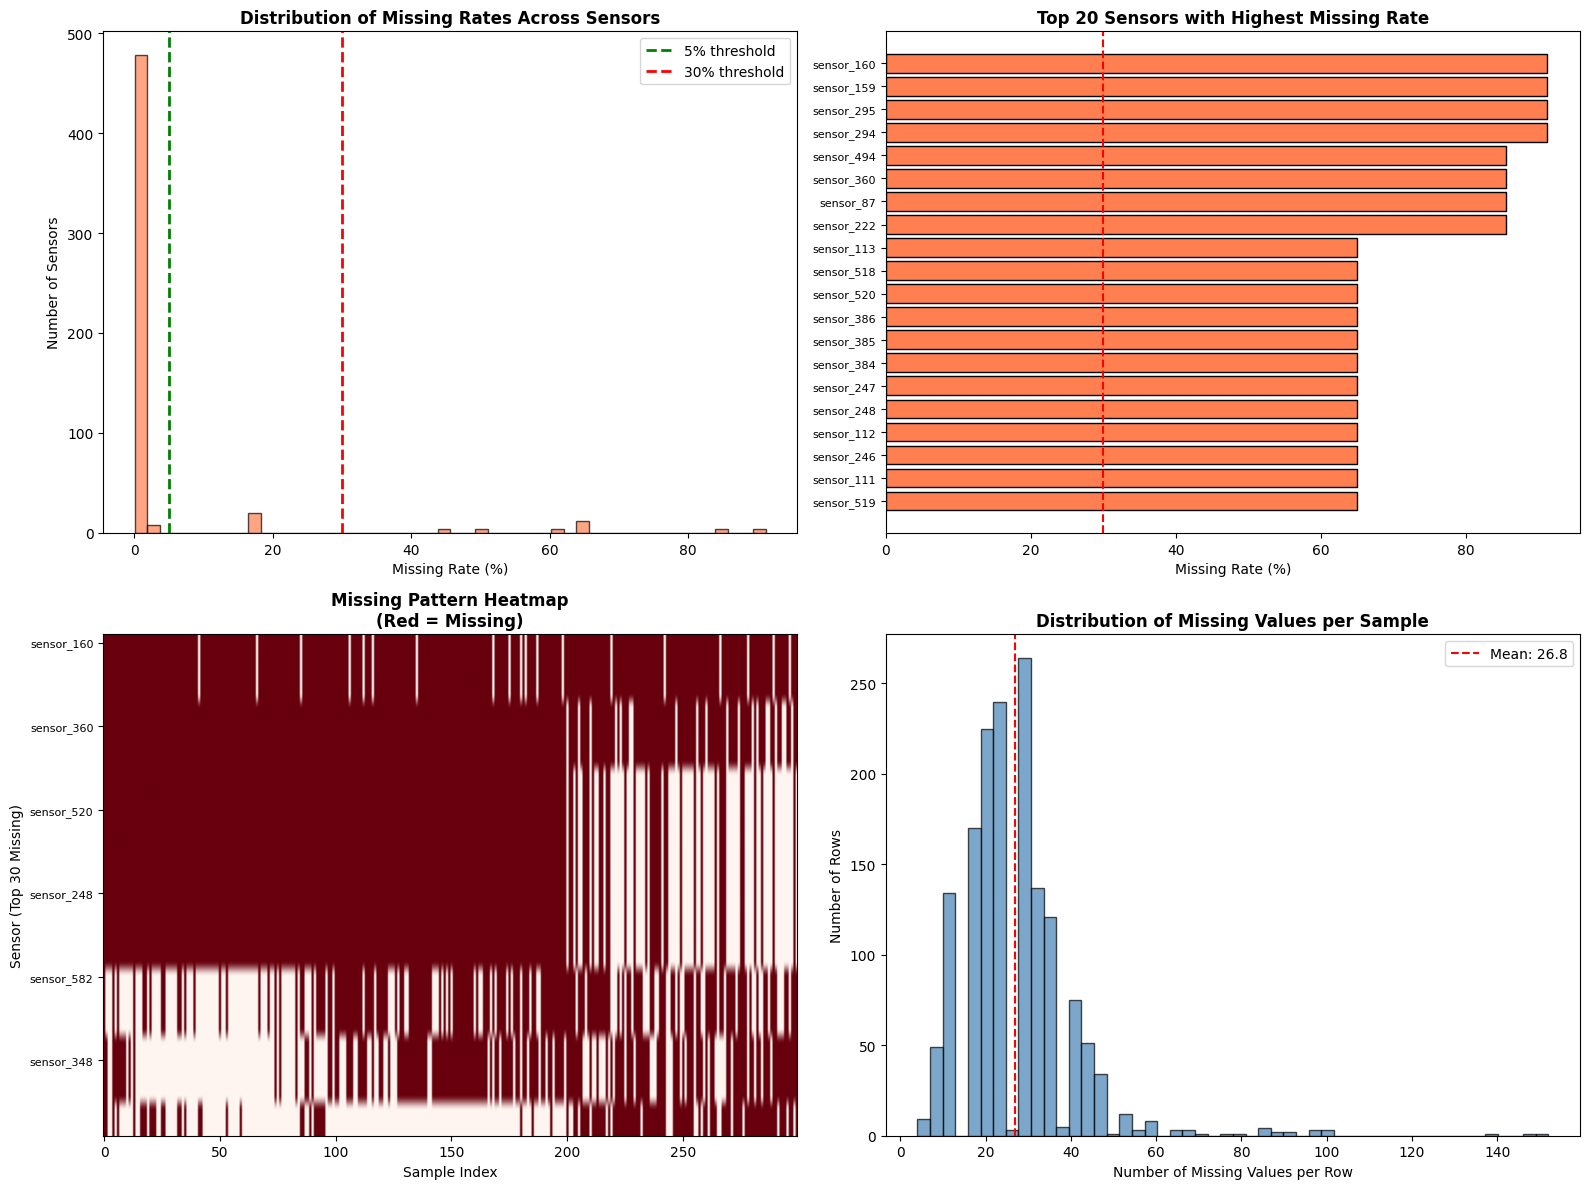


샘플당 평균 결측 센서 수: 26.8개
샘플당 최대 결측 센서 수: 152개


In [78]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. 결측률 분포 히스토그램
ax1 = axes[0, 0]
ax1.hist(missing_pct[missing_pct > 0], bins=50, edgecolor='black', color='coral', alpha=0.7)
ax1.axvline(x=5, color='green', linestyle='--', linewidth=2, label='5% threshold')
ax1.axvline(x=30, color='red', linestyle='--', linewidth=2, label='30% threshold')
ax1.set_xlabel('Missing Rate (%)')
ax1.set_ylabel('Number of Sensors')
ax1.set_title('Distribution of Missing Rates Across Sensors', fontsize=12, fontweight='bold')
ax1.legend()

# 2. 결측률 상위 20개 센서 막대그래프
ax2 = axes[0, 1]
top20 = missing_pct.sort_values(ascending=False).head(20)
ax2.barh(range(len(top20)), top20.values, color='coral', edgecolor='black')
ax2.set_yticks(range(len(top20)))
ax2.set_yticklabels(top20.index, fontsize=8)
ax2.set_xlabel('Missing Rate (%)')
ax2.set_title('Top 20 Sensors with Highest Missing Rate', fontsize=12, fontweight='bold')
ax2.axvline(x=30, color='red', linestyle='--', label='30% threshold')
ax2.invert_yaxis()

# 3. 결측치 히트맵 (샘플 센서)
ax3 = axes[1, 0]
# 결측률 상위 30개 센서 선택
high_missing_sensors = missing_pct.sort_values(ascending=False).head(30).index.tolist()
sample_rows = list(range(0, 100)) + list(range(500, 600)) + list(range(1000, 1100))
sample_data = secom_df.iloc[sample_rows][high_missing_sensors]
im = ax3.imshow(sample_data.isnull().T, aspect='auto', cmap='Reds')
ax3.set_xlabel('Sample Index')
ax3.set_ylabel('Sensor (Top 30 Missing)')
ax3.set_title('Missing Pattern Heatmap\n(Red = Missing)', fontsize=12, fontweight='bold')
ax3.set_yticks(range(0, 30, 5))
ax3.set_yticklabels(high_missing_sensors[::5], fontsize=8)

# 4. 행별 결측치 수 분포
ax4 = axes[1, 1]
row_missing = secom_df[sensor_cols].isnull().sum(axis=1)
ax4.hist(row_missing, bins=50, edgecolor='black', color='steelblue', alpha=0.7)
ax4.set_xlabel('Number of Missing Values per Row')
ax4.set_ylabel('Number of Rows')
ax4.set_title('Distribution of Missing Values per Sample', fontsize=12, fontweight='bold')
ax4.axvline(x=row_missing.mean(), color='red', linestyle='--', 
            label=f'Mean: {row_missing.mean():.1f}')
ax4.legend()

plt.tight_layout()
plt.savefig('secom_missing_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n샘플당 평균 결측 센서 수: {row_missing.mean():.1f}개")
print(f"샘플당 최대 결측 센서 수: {row_missing.max()}개")

## 4.1 결측치 처리 전략 적용

### 전략 1: 고결측률 열 삭제

In [80]:
# 결측률 50% 이상인 열 식별
high_missing_threshold = 50
high_missing_cols = missing_pct[missing_pct > high_missing_threshold].index.tolist()

print(f"=== 결측률 {high_missing_threshold}% 초과 센서 ===")
print(f"삭제 대상: {len(high_missing_cols)}개 센서")
print(f"예시: {high_missing_cols[:5]}")

# 삭제 전 데이터
print(f"\n삭제 전 데이터 크기: {secom_df[sensor_cols].shape}")

# 고결측률 열 삭제
secom_cleaned = secom_df.drop(columns=high_missing_cols)
remaining_sensors = [col for col in secom_cleaned.columns if col.startswith('sensor_')]

print(f"삭제 후 데이터 크기: {secom_cleaned[remaining_sensors].shape}")
print(f"남은 결측치: {secom_cleaned[remaining_sensors].isnull().sum().sum():,}개")

=== 결측률 50% 초과 센서 ===
삭제 대상: 28개 센서
예시: ['sensor_74', 'sensor_75', 'sensor_87', 'sensor_111', 'sensor_112']

삭제 전 데이터 크기: (1567, 592)
삭제 후 데이터 크기: (1567, 564)
남은 결측치: 11,683개


### 전략 2: 중간 결측률 열 - 중앙값 대체

In [81]:
# 결측률 5~50% 열 처리
moderate_missing_threshold_low = 5
moderate_missing_threshold_high = 50

moderate_missing_cols = missing_pct[
    (missing_pct > moderate_missing_threshold_low) & 
    (missing_pct <= moderate_missing_threshold_high)
].index.tolist()

print(f"=== 결측률 {moderate_missing_threshold_low}~{moderate_missing_threshold_high}% 센서 ===")
print(f"중앙값 대체 대상: {len(moderate_missing_cols)}개 센서")

# 중앙값 대체
secom_imputed = secom_cleaned.copy()
for col in moderate_missing_cols:
    if col in secom_imputed.columns:
        median_val = secom_imputed[col].median()
        before_missing = secom_imputed[col].isnull().sum()
        secom_imputed[col] = secom_imputed[col].fillna(median_val)
        
        if before_missing > 0:
            print(f"  {col}: {before_missing}개 → 중앙값({median_val:.2f})으로 대체")

=== 결측률 5~50% 센서 ===
중앙값 대체 대상: 24개 센서
  sensor_114: 715개 → 중앙값(0.46)으로 대체
  sensor_249: 715개 → 중앙값(0.03)으로 대체
  sensor_387: 715개 → 중앙값(0.01)으로 대체
  sensor_521: 715개 → 중앙값(5.83)으로 대체
  sensor_548: 260개 → 중앙값(0.91)으로 대체
  sensor_549: 260개 → 중앙값(403.12)으로 대체
  sensor_550: 260개 → 중앙값(74.08)으로 대체
  sensor_551: 260개 → 중앙값(0.47)으로 대체
  sensor_552: 260개 → 중앙값(16.34)으로 대체
  sensor_553: 260개 → 중앙값(1.15)으로 대체
  sensor_554: 260개 → 중앙값(0.20)으로 대체
  sensor_555: 260개 → 중앙값(7.43)으로 대체
  sensor_556: 260개 → 중앙값(0.48)으로 대체
  sensor_557: 260개 → 중앙값(54.44)으로 대체
  sensor_558: 260개 → 중앙값(4.07)으로 대체
  sensor_559: 260개 → 중앙값(1.53)으로 대체
  sensor_564: 273개 → 중앙값(264.27)으로 대체
  sensor_565: 273개 → 중앙값(0.65)으로 대체
  sensor_566: 273개 → 중앙값(5.16)으로 대체
  sensor_567: 273개 → 중앙값(0.12)으로 대체
  sensor_568: 273개 → 중앙값(2.15)으로 대체
  sensor_569: 273개 → 중앙값(0.05)으로 대체
  sensor_570: 273개 → 중앙값(2.00)으로 대체
  sensor_571: 273개 → 중앙값(16.99)으로 대체


### 전략 3: 저결측률 열 - KNN 또는 중앙값 대체

In [82]:
# 결측률 5% 이하 열
low_missing_cols = missing_pct[
    (missing_pct > 0) & (missing_pct <= 5)
].index.tolist()

print(f"\n=== 결측률 5% 이하 센서 ===")
print(f"대체 대상: {len(low_missing_cols)}개 센서")

# 단순 중앙값 대체 (교육 목적, 실무에서는 KNN Imputer 권장)
for col in low_missing_cols:
    if col in secom_imputed.columns:
        missing_count = secom_imputed[col].isnull().sum()
        if missing_count > 0:
            secom_imputed[col] = secom_imputed[col].fillna(secom_imputed[col].median())

print(f"\n처리 후 총 결측치: {secom_imputed[remaining_sensors].isnull().sum().sum()}개")


=== 결측률 5% 이하 센서 ===
대체 대상: 486개 센서

처리 후 총 결측치: 0개


In [89]:
secom_imputed

,sensor_0,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,sensor_8,sensor_9,...,sensor_578,sensor_579,sensor_584,sensor_585,sensor_586,sensor_587,sensor_588,sensor_589,sensor_590,sensor_591
0,-1,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,...,1.6765,14.9509,0.5005,0.0118,0.0035,2.3630,0.0205,0.0148,0.0046,71.9005
1,-1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,...,1.1065,10.9003,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,1,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,...,2.0952,9.2721,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,-1,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,...,1.7585,8.5831,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,-1,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,...,1.6597,10.9698,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1562,-1,16/10/2008 15:13:00,2899.41,2464.36,2179.7333,3085.3781,1.4843,100.0,82.2467,0.1248,...,1.4879,11.7256,0.4988,0.0143,0.0039,2.8669,0.0068,0.0138,0.0047,203.1720
1563,-1,16/10/2008 20:49:00,3052.31,2522.55,2198.5667,1124.6595,0.8763,100.0,98.4689,0.1205,...,1.0187,17.8379,0.4975,0.0131,0.0036,2.6238,0.0068,0.0138,0.0047,203.1720
1564,-1,17/10/2008 05:26:00,2978.81,2379.78,2206.3000,1110.4967,0.8236,100.0,99.4122,0.1208,...,1.2237,17.7267,0.4987,0.0153,0.0041,3.0590,0.0197,0.0086,0.0025,43.5231
1565,-1,17/10/2008 06:01:00,2894.92,2532.01,2177.0333,1183.7287,1.5726,100.0,98.7978,0.1213,...,1.7085,19.2104,0.5004,0.0178,0.0038,3.5662,0.0262,0.0245,0.0075,93.4941


In [105]:
secom_imputed = secom_imputed.drop(columns=['sensor_1'])

## 4.2 이상치 분석

### 샘플 센서 선택 및 이상치 탐지


In [109]:
# 분석을 위해 결측률이 낮은 센서 10개 선택
low_missing_sensors = missing_pct[missing_pct < 1].index[:10].tolist()

print("=" * 60)
print("SECOM 데이터 이상치 분석 (결측률 <1% 센서)")
print("=" * 60)

# IQR 방법으로 이상치 탐지
outlier_summary = []

for col in low_missing_sensors:
    if col not in secom_imputed.columns:
        continue
    
    data = secom_imputed[col].dropna()
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = ((data < lower) | (data > upper))
    n_outliers = outliers.sum()
    
    outlier_summary.append({
        '센서': col,
        '평균': round(data.mean(), 2),
        '표준편차': round(data.std(), 2),
        'IQR_하한': round(lower, 2),
        'IQR_상한': round(upper, 2),
        '이상치_수': n_outliers,
        '이상치_비율(%)': round(n_outliers / len(data) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
print(outlier_df.to_string(index=False))

SECOM 데이터 이상치 분석 (결측률 <1% 센서)
      센서      평균   표준편차  IQR_하한  IQR_상한  이상치_수  이상치_비율(%)
sensor_0   -0.87   0.50   -1.00   -1.00    104       6.64
sensor_2 3014.44  73.48 2831.85 3191.35     51       3.25
sensor_3 2495.87  80.23 2324.10 2667.53     87       5.55
sensor_4 2200.55  29.38 2125.67 2273.49     31       1.98
sensor_5 1395.38 439.84  324.46 2349.60     51       3.25
sensor_6    4.17  56.10    0.27    2.27     48       3.06
sensor_7  100.00   0.00  100.00  100.00      0       0.00
sensor_8  101.12   6.21   88.05  114.42    102       6.51
sensor_9    0.12   0.01    0.12    0.13     12       0.77


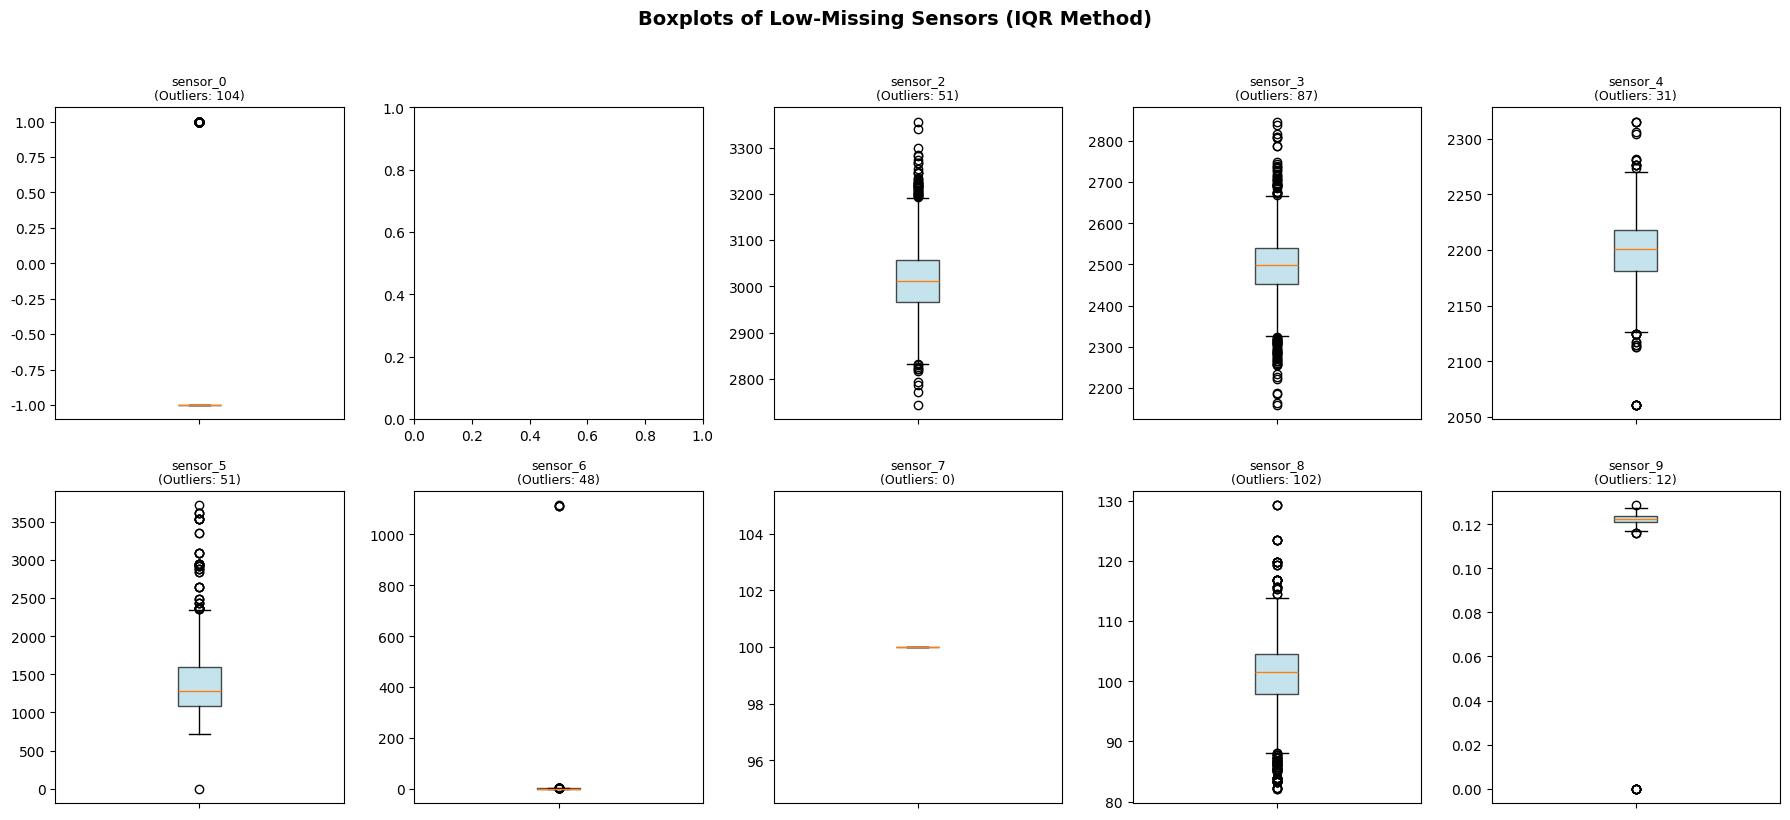

In [110]:
# 이상치 시각화
fig, axes = plt.subplots(2, 5, figsize=(18, 8))

for i, col in enumerate(low_missing_sensors):
    if col not in secom_imputed.columns:
        continue
        
    ax = axes.flatten()[i]
    data = secom_imputed[col].dropna()
    
    # 상자그림
    bp = ax.boxplot(data, vert=True, patch_artist=True)
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][0].set_alpha(0.7)
    
    # 통계 정보
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = ((data < lower) | (data > upper)).sum()
    
    ax.set_title(f'{col}\n(Outliers: {outliers})', fontsize=9)
    ax.tick_params(axis='x', labelbottom=False)

plt.suptitle('Boxplots of Low-Missing Sensors (IQR Method)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [111]:
# 이상치 처리 (클리핑)
secom_final = secom_imputed.copy()
remaining_sensors = [col for col in secom_final.columns if col.startswith('sensor_')]

print("=" * 60)
print("🔧 이상치 처리 (IQR 기반 클리핑)")
print("=" * 60)

total_clipped = 0
for col in remaining_sensors:
    data = secom_final[col]
    
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    # 이상치 수
    n_outliers = ((data < lower) | (data > upper)).sum()
    
    if n_outliers > 0:
        # 클리핑 적용
        secom_final[col] = data.clip(lower, upper)
        total_clipped += n_outliers
        
        if n_outliers > 50:  # 50개 이상인 경우만 출력
            print(f"  {col}: {n_outliers}개 클리핑 (범위: {lower:.2f} ~ {upper:.2f})")

print(f"\n총 클리핑된 데이터 포인트: {total_clipped:,}개")

🔧 이상치 처리 (IQR 기반 클리핑)
  sensor_0: 104개 클리핑 (범위: -1.00 ~ -1.00)
  sensor_2: 51개 클리핑 (범위: 2831.85 ~ 3191.35)
  sensor_3: 87개 클리핑 (범위: 2324.10 ~ 2667.53)
  sensor_5: 51개 클리핑 (범위: 324.46 ~ 2349.60)
  sensor_8: 102개 클리핑 (범위: 88.05 ~ 114.42)
  sensor_24: 53개 클리핑 (범위: 2184.38 ~ 3234.38)
  sensor_25: 195개 클리핑 (범위: -5892.00 ~ -1835.00)
  sensor_26: 122개 클리핑 (범위: -5750.31 ~ 5652.19)
  sensor_33: 354개 클리핑 (범위: 3.11 ~ 3.78)
  sensor_35: 54개 클리핑 (범위: 7.86 ~ 9.78)
  sensor_39: 99개 클리핑 (범위: 65.59 ~ 66.80)
  sensor_40: 85개 클리핑 (범위: 85.94 ~ 87.64)
  sensor_41: 139개 클리핑 (범위: 116.63 ~ 120.33)
  sensor_42: 330개 클리핑 (범위: 66.83 ~ 88.19)
  sensor_43: 195개 클리핑 (범위: 1.47 ~ 4.74)
  sensor_61: 201개 클리핑 (범위: -11.15 ~ 13.63)
  sensor_63: 62개 클리핑 (범위: 9.82 ~ 11.05)
  sensor_65: 56개 클리핑 (범위: 1.47 ~ 25.24)
  sensor_66: 67개 클리핑 (범위: 9.24 ~ 30.93)
  sensor_67: 57개 클리핑 (범위: 12.83 ~ 40.16)
  sensor_69: 121개 클리핑 (범위: 0.63 ~ 1.32)
  sensor_73: 119개 클리핑 (범위: 45.80 ~ 157.22)
  sensor_81: 93개 클리핑 (범위: -0.05 ~ 0.05)
  sensor_8

# 핵심 정리

## 결측치 처리

| 결측 비율 | 권장 방법 | 코드 |
|----------|----------|------|
| < 5% | 삭제 또는 단순 대체 | `df.dropna()` 또는 `df.fillna(median)` |
| 5~15% | 중앙값/그룹별 평균 | `groupby().transform(fillna)` |
| 15~30% | 보간법, 예측 모델 | `df.interpolate()` |
| > 30% | 열 삭제 고려 | `df.drop(columns=[...])` |

## 이상치 탐지

| 방법 | 수식 | 적합한 경우 |
|------|------|------------|
| **IQR** | $Q_1 - 1.5 \times IQR$ ~ $Q_3 + 1.5 \times IQR$ | 비대칭 분포 |
| **Z-score** | $\|Z\| > 2$ 또는 $3$ | 정규분포에 가까울 때 |

## 이상치 처리

| 전략 | 코드 | 사용 시점 |
|------|------|----------|
| **삭제** | `df[~outliers]` | 명백한 오류 |
| **클리핑** | `df.clip(lower, upper)` | 극단값 완화 |
| **대체** | `df.loc[outliers] = median` | 측정 오류 |
| **플래그** | `df['is_outlier'] = outliers` | 분석 필요 시 |

---